In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from pathlib import Path
import os

DATA_ROOT = Path("/content/drive/MyDrive/PKG - C-NMC 2019/C-NMC_training_data")

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("DATA_ROOT:", DATA_ROOT)

for item in DATA_ROOT.parent.iterdir():
    print(item)

DATA_ROOT exists: True
DATA_ROOT: /content/drive/MyDrive/PKG - C-NMC 2019/C-NMC_training_data
/content/drive/MyDrive/PKG - C-NMC 2019/C-NMC_Leukemia.sums
/content/drive/MyDrive/PKG - C-NMC 2019/C-NMC_test_final_phase_data
/content/drive/MyDrive/PKG - C-NMC 2019/C-NMC_training_data
/content/drive/MyDrive/PKG - C-NMC 2019/C-NMC_test_prelim_phase_data


In [ ]:
import os, random, torch
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

DATA_ROOT = Path("/content/drive/MyDrive/PKG - C-NMC 2019/C-NMC_training_data")

all_paths = []
all_labels = []

class_map = {"all": 0, "hem": 1}

for fold in ["fold_0", "fold_1", "fold_2"]:
    for cls in ["all", "hem"]:
        folder = DATA_ROOT / fold / cls
        for img in folder.glob("*"):
            if img.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]:
                all_paths.append(str(img))
                all_labels.append(class_map[cls])

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print(len(train_paths), len(val_paths), len(test_paths))

8528 1066 1067


In [ ]:
import cv2
from PIL import Image

class CLAHETransform:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __call__(self, img):
        img = np.array(img)
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l = self.clahe.apply(l)
        lab = cv2.merge((l, a, b))
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class BloodDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
BATCH_SIZE = 32

train_dataset = BloodDataset(train_paths, train_labels, train_transform)
val_dataset = BloodDataset(val_paths, val_labels, eval_transform)
test_dataset = BloodDataset(test_paths, test_labels, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
from collections import Counter

counter = Counter(train_labels)
total = sum(counter.values())

class_weights = torch.tensor([
    total / (2 * counter[0]),
    total / (2 * counter[1])
], dtype=torch.float)

print(counter)
print(class_weights)

Counter({0: 5817, 1: 2711})
tensor([0.7330, 1.5729])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

model = model.to(device)

cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 249MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
from pathlib import Path

DATA_ROOT = Path("/content/C-NMC/C-NMC_training_data")
print(DATA_ROOT.exists())

True


In [ ]:
for fold in ["fold_0", "fold_1", "fold_2"]:
    for cls in ["all", "hem"]:
        path = DATA_ROOT / fold / cls
        print(path, path.exists(), len(list(path.glob("*"))))

/content/C-NMC/C-NMC_training_data/fold_0/all True 642
/content/C-NMC/C-NMC_training_data/fold_0/hem False 0
/content/C-NMC/C-NMC_training_data/fold_1/all False 0
/content/C-NMC/C-NMC_training_data/fold_1/hem False 0
/content/C-NMC/C-NMC_training_data/fold_2/all False 0
/content/C-NMC/C-NMC_training_data/fold_2/hem False 0


In [ ]:
import os

for root, dirs, files in os.walk("/content/C-NMC"):
    print(root)

/content/C-NMC
/content/C-NMC/C-NMC_training_data
/content/C-NMC/C-NMC_training_data/fold_0
/content/C-NMC/C-NMC_training_data/fold_0/all


In [ ]:
!rm -rf "/content/C-NMC"
!cp -r "/content/drive/MyDrive/PKG - C-NMC 2019" "/content/C-NMC"

In [ ]:
import os

for root, dirs, files in os.walk("/content/C-NMC"):
    print(root)

/content/C-NMC
/content/C-NMC/C-NMC_test_prelim_phase_data
/content/C-NMC/C-NMC_test_final_phase_data
/content/C-NMC/C-NMC_training_data
/content/C-NMC/C-NMC_training_data/fold_0
/content/C-NMC/C-NMC_training_data/fold_0/all
/content/C-NMC/C-NMC_training_data/fold_0/hem
/content/C-NMC/C-NMC_training_data/fold_2
/content/C-NMC/C-NMC_training_data/fold_2/all
/content/C-NMC/C-NMC_training_data/fold_2/hem
/content/C-NMC/C-NMC_training_data/fold_1
/content/C-NMC/C-NMC_training_data/fold_1/all
/content/C-NMC/C-NMC_training_data/fold_1/hem


In [ ]:
from pathlib import Path

DATA_ROOT = Path("/content/C-NMC/C-NMC_training_data")

In [ ]:
from sklearn.model_selection import train_test_split

all_paths = []
all_labels = []

class_map = {"all": 0, "hem": 1}

for fold in ["fold_0", "fold_1", "fold_2"]:
    for cls in ["all", "hem"]:
        folder = DATA_ROOT / fold / cls
        for img in folder.glob("*"):
            if img.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]:
                all_paths.append(str(img))
                all_labels.append(class_map[cls])

print("Total:", len(all_paths))

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print(len(train_paths), len(val_paths), len(test_paths))

Total: 10661
8528 1066 1067


In [ ]:
!pip install opencv-python

In [ ]:
!pip install opencv-python -qimport cv2
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CLAHETransform:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __call__(self, img):
        img = np.array(img)
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l = self.clahe.apply(l)
        lab = cv2.merge((l, a, b))
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class BloodDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [ ]:
!pip install opencv-python -q

In [ ]:
import cv2
print("OpenCV working")

OpenCV working


In [ ]:
import cv2
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CLAHETransform:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __call__(self, img):
        img = np.array(img)
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l = self.clahe.apply(l)
        lab = cv2.merge((l, a, b))
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)

train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class BloodDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
BATCH_SIZE = 128

train_dataset = BloodDataset(train_paths, train_labels, train_transform)
val_dataset = BloodDataset(val_paths, val_labels, eval_transform)
test_dataset = BloodDataset(test_paths, test_labels, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
import torch
from collections import Counter

counter = Counter(train_labels)
total = sum(counter.values())

class_weights = torch.tensor([
    total / (2 * counter[0]),
    total / (2 * counter[1])
], dtype=torch.float)

print(counter)
print(class_weights)

Counter({0: 5817, 1: 2711})
tensor([0.7330, 1.5729])


In [ ]:
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.get_device_name(0))

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

model = model.to(device)

NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
from tqdm import tqdm
import torch

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 5
best_val_acc = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_resnet50_stage1.pth")
        print("✅ Best model saved")

100%|██████████| 67/67 [00:08<00:00,  8.06it/s]



Epoch 1/5
Train Loss: 0.5733
Val Loss: 0.5389
Val Accuracy: 0.7608
✅ Best model saved


100%|██████████| 67/67 [00:08<00:00,  8.31it/s]



Epoch 2/5
Train Loss: 0.5117
Val Loss: 0.5129
Val Accuracy: 0.7908
✅ Best model saved


100%|██████████| 67/67 [00:07<00:00,  8.54it/s]



Epoch 3/5
Train Loss: 0.4967
Val Loss: 0.5255
Val Accuracy: 0.7420


100%|██████████| 67/67 [00:08<00:00,  8.36it/s]



Epoch 4/5
Train Loss: 0.5006
Val Loss: 0.4890
Val Accuracy: 0.8311
✅ Best model saved


100%|██████████| 67/67 [00:08<00:00,  8.10it/s]



Epoch 5/5
Train Loss: 0.4880
Val Loss: 0.4951
Val Accuracy: 0.7852


In [ ]:
for param in model.parameters():
    param.requires_grad = False

# unfreeze layer4 + fc
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
from tqdm import tqdm
import torch

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 8
best_val_acc = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_resnet50_stage1.pth")
        print("✅ Best model saved")

100%|██████████| 67/67 [00:07<00:00,  8.38it/s]



Epoch 1/8
Train Loss: 0.4796
Val Loss: 0.4815
Val Accuracy: 0.8133
✅ Best model saved


100%|██████████| 67/67 [00:08<00:00,  8.35it/s]



Epoch 2/8
Train Loss: 0.4729
Val Loss: 0.4906
Val Accuracy: 0.7777


100%|██████████| 67/67 [00:08<00:00,  8.24it/s]


...


Epoch 6/8
Train Loss: 0.4658
Val Loss: 0.4773
Val Accuracy: 0.7964


100%|██████████| 67/67 [00:07<00:00,  8.45it/s]



Epoch 7/8
Train Loss: 0.4583
Val Loss: 0.4759
Val Accuracy: 0.7880


100%|██████████| 67/67 [00:07<00:00,  8.49it/s]



Epoch 8/8
Train Loss: 0.4590
Val Loss: 0.4670
Val Accuracy: 0.8002


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))

print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=["ALL", "HEM"]))

Confusion Matrix:
[[592 135]
 [ 78 261]]

Classification Report:
              precision    recall  f1-score   support

         ALL       0.88      0.81      0.85       727
         HEM       0.66      0.77      0.71       339

    accuracy                           0.80      1066
   macro avg       0.77      0.79      0.78      1066
weighted avg       0.81      0.80      0.80      1066



In [ ]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class BloodDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
BATCH_SIZE = 128

train_dataset = BloodDataset(train_paths, train_labels, train_transform)
val_dataset = BloodDataset(val_paths, val_labels, eval_transform)
test_dataset = BloodDataset(test_paths, test_labels, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

model = model.to(device)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 10
best_val_acc = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_resnet50_clean.pth")
        print("✅ Best model saved")

Epoch 1/10: 100%|██████████| 67/67 [00:03<00:00, 19.68it/s]



Epoch 1/10
Train Loss: 0.5250
Val Loss: 0.4801
Val Accuracy: 0.8152
✅ Best model saved


Epoch 2/10: 100%|██████████| 67/67 [00:03<00:00, 19.61it/s]



Epoch 2/10
Train Loss: 0.4028
Val Loss: 0.4017
Val Accuracy: 0.8236
✅ Best model saved


Epoch 3/10: 100%|██████████| 67/67 [00:03<00:00, 19.78it/s]


...


Epoch 8/10
Train Loss: 0.2179
Val Loss: 0.2679
Val Accuracy: 0.8884


Epoch 9/10: 100%|██████████| 67/67 [00:03<00:00, 19.83it/s]



Epoch 9/10
Train Loss: 0.2095
Val Loss: 0.2265
Val Accuracy: 0.9081
✅ Best model saved


Epoch 10/10: 100%|██████████| 67/67 [00:03<00:00, 19.59it/s]



Epoch 10/10
Train Loss: 0.1996
Val Loss: 0.2324
Val Accuracy: 0.9146
✅ Best model saved


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))

print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=["ALL", "HEM"]))

Confusion Matrix:
[[704  23]
 [ 69 270]]

Classification Report:
              precision    recall  f1-score   support

         ALL       0.91      0.97      0.94       727
         HEM       0.92      0.80      0.85       339

    accuracy                           0.91      1066
   macro avg       0.92      0.88      0.90      1066
weighted avg       0.91      0.91      0.91      1066



In [ ]:
for param in model.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [ ]:
from tqdm import tqdm
import torch

# Unfreeze full ResNet50
for param in model.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 40
best_val_acc = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Fine Tune Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nFine Tune Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_resnet50_final.pth")
        print("✅ Best final model saved")

Fine Tune Epoch 1/40: 100%|██████████| 67/67 [00:04<00:00, 14.10it/s]



Fine Tune Epoch 1/40
Train Loss: 0.1899
Val Loss: 0.2212
Val Accuracy: 0.9231
✅ Best final model saved


Fine Tune Epoch 2/40: 100%|██████████| 67/67 [00:04<00:00, 14.06it/s]



Fine Tune Epoch 2/40
Train Loss: 0.1697
Val Loss: 0.2056
Val Accuracy: 0.9343
✅ Best final model saved


Fine Tune Epoch 3/40: 100%|██████████| 67/67 [00:04<00:00, 14.61it/s]


...


Fine Tune Epoch 38/40
Train Loss: 0.0520
Val Loss: 0.1575
Val Accuracy: 0.9597
✅ Best final model saved


Fine Tune Epoch 39/40: 100%|██████████| 67/67 [00:04<00:00, 14.27it/s]



Fine Tune Epoch 39/40
Train Loss: 0.0553
Val Loss: 0.1957
Val Accuracy: 0.9503


Fine Tune Epoch 40/40: 100%|██████████| 67/67 [00:04<00:00, 14.60it/s]



Fine Tune Epoch 40/40
Train Loss: 0.0485
Val Loss: 0.1797
Val Accuracy: 0.9484


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))

print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=["ALL", "HEM"]))

Confusion Matrix:
[[714  13]
 [ 39 300]]

Classification Report:
              precision    recall  f1-score   support

         ALL       0.95      0.98      0.96       727
         HEM       0.96      0.88      0.92       339

    accuracy                           0.95      1066
   macro avg       0.95      0.93      0.94      1066
weighted avg       0.95      0.95      0.95      1066



In [ ]:
model.load_state_dict(torch.load("/content/best_resnet50_final.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # HEM probability

        all_probs.extend(probs.cpu().numpy())
        all_true.extend(labels.numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

best_acc = 0
best_threshold = 0.5

for threshold in np.arange(0.20, 0.81, 0.01):
    preds = (all_probs >= threshold).astype(int)
    acc = accuracy_score(all_true, preds)

    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Val Accuracy:", best_acc)

final_preds = (all_probs >= best_threshold).astype(int)

print(confusion_matrix(all_true, final_preds))
print(classification_report(all_true, final_preds, target_names=["ALL", "HEM"]))

Best Threshold: 0.49000000000000027
Best Val Accuracy: 0.9577861163227017
[[716  11]
 [ 34 305]]
              precision    recall  f1-score   support

         ALL       0.95      0.98      0.97       727
         HEM       0.97      0.90      0.93       339

    accuracy                           0.96      1066
   macro avg       0.96      0.94      0.95      1066
weighted avg       0.96      0.96      0.96      1066



In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

model.load_state_dict(torch.load("/content/best_resnet50_final.pth"))
model.eval()

tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(5, 5)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(-5, -5)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
]

class BloodDatasetTTA(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        return img, self.labels[idx]


all_tta_probs = []
true_labels = None

for i, tfm in enumerate(tta_transforms):
    dataset = BloodDatasetTTA(val_paths, val_labels, tfm)
    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    probs_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            probs_list.extend(probs.cpu().numpy())
            labels_list.extend(labels.numpy())

    all_tta_probs.append(np.array(probs_list))

    if true_labels is None:
        true_labels = np.array(labels_list)

avg_probs = np.mean(all_tta_probs, axis=0)

best_acc = 0
best_threshold = 0.5

for threshold in np.arange(0.20, 0.81, 0.001):
    preds = (avg_probs >= threshold).astype(int)
    acc = accuracy_score(true_labels, preds)

    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

print("Best TTA Threshold:", best_threshold)
print("Best TTA Val Accuracy:", best_acc)

final_preds = (avg_probs >= best_threshold).astype(int)

print(confusion_matrix(true_labels, final_preds))
print(classification_report(true_labels, final_preds, target_names=["ALL", "HEM"]))

Best TTA Threshold: 0.4250000000000002
Best TTA Val Accuracy: 0.9662288930581614
[[716  11]
 [ 25 314]]
              precision    recall  f1-score   support

         ALL       0.97      0.98      0.98       727
         HEM       0.97      0.93      0.95       339

    accuracy                           0.97      1066
   macro avg       0.97      0.96      0.96      1066
weighted avg       0.97      0.97      0.97      1066



In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

convnext.classifier[2] = nn.Sequential(
    nn.Linear(convnext.classifier[2].in_features, 256),
    nn.GELU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

convnext = convnext.to(device)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 315MB/s] 


In [ ]:
for param in convnext.features.parameters():
    param.requires_grad = False

for param in convnext.classifier.parameters():
    param.requires_grad = True

In [ ]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    convnext.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 40
best_val_acc = 0

for epoch in range(EPOCHS):
    convnext.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"ConvNeXt Head Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = convnext(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    convnext.eval()
    correct, total, val_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = convnext(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nConvNeXt Head Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(convnext.state_dict(), "/content/best_convnext_head.pth")
        print("✅ Best ConvNeXt head saved")

ConvNeXt Head Epoch 1/40: 100%|██████████| 67/67 [00:03<00:00, 19.28it/s]



ConvNeXt Head Epoch 1/40
Train Loss: 0.3838
Val Loss: 0.3697
Val Accuracy: 0.8433
✅ Best ConvNeXt head saved


ConvNeXt Head Epoch 2/40: 100%|██████████| 67/67 [00:03<00:00, 19.31it/s]



ConvNeXt Head Epoch 2/40
Train Loss: 0.3830
Val Loss: 0.3657
Val Accuracy: 0.8471
✅ Best ConvNeXt head saved


ConvNeXt Head Epoch 3/40: 100%|██████████| 67/67 [00:03<00:00, 18.96it/s]


...


ConvNeXt Head Epoch 38/40
Train Loss: 0.2932
Val Loss: 0.2944
Val Accuracy: 0.8696


ConvNeXt Head Epoch 39/40: 100%|██████████| 67/67 [00:03<00:00, 19.27it/s]



ConvNeXt Head Epoch 39/40
Train Loss: 0.2924
Val Loss: 0.2944
Val Accuracy: 0.8696


ConvNeXt Head Epoch 40/40: 100%|██████████| 67/67 [00:03<00:00, 19.19it/s]



ConvNeXt Head Epoch 40/40
Train Loss: 0.2926
Val Loss: 0.2945
Val Accuracy: 0.8696


In [ ]:
for param in convnext.features.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    convnext.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

EPOCHS = 40
best_val_acc = 0

for epoch in range(EPOCHS):
    convnext.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"ConvNeXt FineTune Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = convnext(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    convnext.eval()
    correct, total, val_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = convnext(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nConvNeXt FineTune Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(convnext.state_dict(), "/content/best_convnext_final.pth")
        print("✅ Best ConvNeXt final saved")

ConvNeXt FineTune Epoch 1/40: 100%|██████████| 67/67 [00:10<00:00,  6.34it/s]



ConvNeXt FineTune Epoch 1/40
Train Loss: 0.2972
Val Loss: 0.2935
Val Accuracy: 0.8724
✅ Best ConvNeXt final saved


ConvNeXt FineTune Epoch 2/40: 100%|██████████| 67/67 [00:04<00:00, 14.25it/s]



ConvNeXt FineTune Epoch 2/40
Train Loss: 0.2647
Val Loss: 0.2394
Val Accuracy: 0.9053
✅ Best ConvNeXt final saved


ConvNeXt FineTune Epoch 3/40: 100%|██████████| 67/67 [00:04<00:00, 13.81it/s]


...


ConvNeXt FineTune Epoch 38/40
Train Loss: 0.0734
Val Loss: 0.1172
Val Accuracy: 0.9615


ConvNeXt FineTune Epoch 39/40: 100%|██████████| 67/67 [00:04<00:00, 14.26it/s]



ConvNeXt FineTune Epoch 39/40
Train Loss: 0.0778
Val Loss: 0.1061
Val Accuracy: 0.9681
✅ Best ConvNeXt final saved


ConvNeXt FineTune Epoch 40/40: 100%|██████████| 67/67 [00:04<00:00, 14.25it/s]



ConvNeXt FineTune Epoch 40/40
Train Loss: 0.0691
Val Loss: 0.1113
Val Accuracy: 0.9690
✅ Best ConvNeXt final saved


In [ ]:
import torchvision.models as models
import torch.nn as nn

effnet = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

effnet.classifier[1] = nn.Sequential(
    nn.Linear(effnet.classifier[1].in_features, 256),
    nn.SiLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

effnet = effnet.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 104MB/s]


In [ ]:
for param in effnet.features.parameters():
    param.requires_grad = False

for param in effnet.classifier.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    effnet.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.5
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 5
best_val_acc = 0

for epoch in range(EPOCHS):
    effnet.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = effnet(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    effnet.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = effnet(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1} Val Acc: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(effnet.state_dict(), "/content/best_effnet.pth")

Epoch 1 Val Acc: 0.8218
Epoch 2 Val Acc: 0.8330
Epoch 3 Val Acc: 0.8349
Epoch 4 Val Acc: 0.8386
Epoch 5 Val Acc: 0.8396


In [ ]:
for param in effnet.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    effnet.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 40
best_val_acc = 0

for epoch in range(EPOCHS):
    effnet.train()

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = effnet(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    effnet.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = effnet(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"FineTune Epoch {epoch+1} Val Acc: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(effnet.state_dict(), "/content/best_effnet_final.pth")

FineTune Epoch 1 Val Acc: 0.8518
FineTune Epoch 2 Val Acc: 0.8537
FineTune Epoch 3 Val Acc: 0.8565
FineTune Epoch 4 Val Acc: 0.8640
FineTune Epoch 5 Val Acc: 0.8649
FineTune Epoch 6 Val Acc: 0.8659
FineTune Epoch 7 Val Acc: 0.8659
FineTune Epoch 8 Val Acc: 0.8677
FineTune Epoch 9 Val Acc: 0.8649
FineTune Epoch 10 Val Acc: 0.8696
FineTune Epoch 11 Val Acc: 0.8649
FineTune Epoch 12 Val Acc: 0.8659
FineTune Epoch 13 Val Acc: 0.8687
FineTune Epoch 14 Val Acc: 0.8696
FineTune Epoch 15 Val Acc: 0.8743
FineTune Epoch 16 Val Acc: 0.8724
FineTune Epoch 17 Val Acc: 0.8743
FineTune Epoch 18 Val Acc: 0.8762
FineTune Epoch 19 Val Acc: 0.8771
FineTune Epoch 20 Val Acc: 0.8865
FineTune Epoch 21 Val Acc: 0.8912
FineTune Epoch 22 Val Acc: 0.8865
FineTune Epoch 23 Val Acc: 0.8884
FineTune Epoch 24 Val Acc: 0.8921
FineTune Epoch 25 Val Acc: 0.8940
FineTune Epoch 26 Val Acc: 0.8968
FineTune Epoch 27 Val Acc: 0.8949
FineTune Epoch 28 Val Acc: 0.8949
FineTune Epoch 29 Val Acc: 0.8977
FineTune Epoch 30 Val A

In [ ]:
effnet.load_state_dict(torch.load("/content/best_effnet_final.pth"))
effnet = effnet.to(device)

In [ ]:
for param in effnet.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    effnet.parameters(),
    lr=3e-6,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)

scaler = torch.amp.GradScaler("cuda")

In [ ]:
from tqdm import tqdm
import torch

EPOCHS = 40
best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    # ================= TRAIN =================
    effnet.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"EffNet FineTune Epoch {epoch+1}/{EPOCHS} - Training"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = effnet(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ================= VALIDATION =================
    effnet.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"EffNet FineTune Epoch {epoch+1}/{EPOCHS} - Validation"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = effnet(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    print(f"\nEffNet FineTune Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(effnet.state_dict(), "/content/best_effnet_final_v2.pth")
        print("✅ Best EfficientNet model saved")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("🛑 Early stopping triggered")
            break

EffNet FineTune Epoch 1/40 - Validation: 100%|██████████| 9/9 [00:02<00:00,  3.48it/s]



EffNet FineTune Epoch 1/40
Train Loss: 0.2366
Val Loss: 0.2273
Val Accuracy: 0.9053
✅ Best EfficientNet model saved


EffNet FineTune Epoch 2/40 - Validation: 100%|██████████| 9/9 [00:00<00:00, 15.24it/s]



EffNet FineTune Epoch 2/40
Train Loss: 0.2360
Val Loss: 0.2292
Val Accuracy: 0.9099
✅ Best EfficientNet model saved


EffNet FineTune Epoch 3/40 - Validation: 100%|██████████| 9/9 [00:00<00:00, 13.73it/s]


...


EffNet FineTune Epoch 15/40
Train Loss: 0.2237
Val Loss: 0.2180
Val Accuracy: 0.9128
⚠️ No improvement. Patience: 3/5


EffNet FineTune Epoch 16/40 - Validation: 100%|██████████| 9/9 [00:00<00:00, 14.69it/s]



EffNet FineTune Epoch 16/40
Train Loss: 0.2249
Val Loss: 0.2172
Val Accuracy: 0.9156
⚠️ No improvement. Patience: 4/5


EffNet FineTune Epoch 17/40 - Validation: 100%|██████████| 9/9 [00:00<00:00, 14.52it/s]


EffNet FineTune Epoch 17/40
Train Loss: 0.2281
Val Loss: 0.2172
Val Accuracy: 0.9118
⚠️ No improvement. Patience: 5/5
🛑 Early stopping triggered


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

effnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)

effnet.classifier[1] = nn.Sequential(
    nn.Linear(effnet.classifier[1].in_features, 512),
    nn.SiLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 2)
)

effnet = effnet.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 200MB/s]


In [ ]:
for param in effnet.features.parameters():
    param.requires_grad = False

for param in effnet.classifier.parameters():
    param.requires_grad = True

In [ ]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    effnet.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 15
best_val_acc = 0

for epoch in range(EPOCHS):
    effnet.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"EffNet-B4 Head Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = effnet(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    effnet.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = effnet(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nEffNet-B4 Head Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(effnet.state_dict(), "/content/best_effnet_b4_head.pth")
        print("✅ Best EfficientNet-B4 head saved")

EffNet-B4 Head Epoch 1/15: 100%|██████████| 67/67 [00:06<00:00,  9.65it/s]



EffNet-B4 Head Epoch 1/15
Train Loss: 0.4781
Val Loss: 0.4283
Val Accuracy: 0.8161
✅ Best EfficientNet-B4 head saved


EffNet-B4 Head Epoch 2/15: 100%|██████████| 67/67 [00:03<00:00, 18.61it/s]



EffNet-B4 Head Epoch 2/15
Train Loss: 0.4362
Val Loss: 0.4208
Val Accuracy: 0.8133


EffNet-B4 Head Epoch 3/15: 100%|██████████| 67/67 [00:03<00:00, 18.01it/s]


...


EffNet-B4 Head Epoch 13/15
Train Loss: 0.4128
Val Loss: 0.4021
Val Accuracy: 0.8311


EffNet-B4 Head Epoch 14/15: 100%|██████████| 67/67 [00:03<00:00, 18.55it/s]



EffNet-B4 Head Epoch 14/15
Train Loss: 0.4109
Val Loss: 0.3937
Val Accuracy: 0.8293


EffNet-B4 Head Epoch 15/15: 100%|██████████| 67/67 [00:03<00:00, 18.61it/s]



EffNet-B4 Head Epoch 15/15
Train Loss: 0.4115
Val Loss: 0.3956
Val Accuracy: 0.8358
✅ Best EfficientNet-B4 head saved


In [ ]:
for param in effnet.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    effnet.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)

EPOCHS = 40
best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    effnet.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"EffNet-B4 FineTune Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = effnet(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    effnet.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = effnet(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nEffNet-B4 FineTune Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(effnet.state_dict(), "/content/best_effnet_b4_final.pth")
        print("✅ Best EfficientNet-B4 final saved")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("🛑 Early stopping triggered")
            break

EffNet-B4 FineTune Epoch 1/40: 100%|██████████| 67/67 [00:13<00:00,  4.83it/s]



EffNet-B4 FineTune Epoch 1/40
Train Loss: 0.3994
Val Loss: 0.3894
Val Accuracy: 0.8311
✅ Best EfficientNet-B4 final saved


EffNet-B4 FineTune Epoch 2/40: 100%|██████████| 67/67 [00:07<00:00,  8.88it/s]



EffNet-B4 FineTune Epoch 2/40
Train Loss: 0.3988
Val Loss: 0.3837
Val Accuracy: 0.8368
✅ Best EfficientNet-B4 final saved


EffNet-B4 FineTune Epoch 3/40: 100%|██████████| 67/67 [00:07<00:00,  8.88it/s]


...


EffNet-B4 FineTune Epoch 11/40
Train Loss: 0.3709
Val Loss: 0.3588
Val Accuracy: 0.8518
⚠️ No improvement. Patience: 3/5


EffNet-B4 FineTune Epoch 12/40: 100%|██████████| 67/67 [00:07<00:00,  8.81it/s]



EffNet-B4 FineTune Epoch 12/40
Train Loss: 0.3649
Val Loss: 0.3563
Val Accuracy: 0.8508
⚠️ No improvement. Patience: 4/5


EffNet-B4 FineTune Epoch 13/40: 100%|██████████| 67/67 [00:07<00:00,  8.83it/s]



EffNet-B4 FineTune Epoch 13/40
Train Loss: 0.3615
Val Loss: 0.3605
Val Accuracy: 0.8499
⚠️ No improvement. Patience: 5/5
🛑 Early stopping triggered


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet50(weights=None)
resnet.fc = nn.Sequential(
    nn.Linear(resnet.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)
resnet = resnet.to(device)

convnext_model = models.convnext_tiny(weights=None)
convnext_model.classifier[2] = nn.Sequential(
    nn.Linear(convnext_model.classifier[2].in_features, 256),
    nn.GELU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)
convnext_model = convnext_model.to(device)

effnet = models.efficientnet_b3(weights=None)
effnet.classifier[1] = nn.Sequential(
    nn.Linear(effnet.classifier[1].in_features, 256),
    nn.SiLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)
effnet = effnet.to(device)

print("Models initialized ✅")

Models initialized ✅


In [ ]:
resnet.load_state_dict(torch.load("/content/best_resnet50_final.pth"))
convnext_model.load_state_dict(torch.load("/content/best_convnext_final.pth"))
effnet.load_state_dict(torch.load("/content/best_effnet_final_v2.pth"))

resnet.eval()
convnext_model.eval()
effnet.eval()

print("Weights loaded ✅")

Weights loaded ✅


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import torch

def evaluate_model(model, loader, name):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_true = np.array(all_true)

    acc = accuracy_score(all_true, all_preds)
    precision = precision_score(all_true, all_preds)
    recall = recall_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds)

    print("\n" + "="*50)
    print(f"{name} RESULTS")
    print("="*50)

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_true, all_preds))

    print("\nMetrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nDetailed Report:")
    print(classification_report(all_true, all_preds, target_names=["ALL", "HEM"]))

In [ ]:
evaluate_model(resnet, val_loader, "ResNet50")
evaluate_model(convnext_model, val_loader, "ConvNeXt")
evaluate_model(effnet, val_loader, "EfficientNet")


ResNet50 RESULTS

Confusion Matrix:
[[716  11]
 [ 34 305]]

Metrics:
Accuracy : 0.9578
Precision: 0.9652
Recall   : 0.8997
F1-score : 0.9313

Detailed Report:
              precision    recall  f1-score   support

         ALL       0.95      0.98      0.97       727
         HEM       0.97      0.90      0.93       339

    accuracy                           0.96      1066
   macro avg       0.96      0.94      0.95      1066
weighted avg       0.96      0.96      0.96      1066


ConvNeXt RESULTS

Confusion Matrix:
[[726   1]
 [ 33 306]]

Metrics:
Accuracy : 0.9681
Precision: 0.9967
Recall   : 0.9027
F1-score : 0.9474

Detailed Report:
              precision    recall  f1-score   support

         ALL       0.96      1.00      0.98       727
         HEM       1.00      0.90      0.95       339

    accuracy                           0.97      1066
   macro avg       0.98      0.95      0.96      1066
weighted avg       0.97      0.97      0.97      1066


EfficientNet RESULTS

Con

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

def get_metrics(model, loader):
    all_preds = []
    all_true = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    recall = recall_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds)

    return acc, recall, f1


# Collect metrics
models_names = ["ResNet50", "ConvNeXt", "EfficientNet"]

metrics = [
    get_metrics(resnet, val_loader),
    get_metrics(convnext_model, val_loader),
    get_metrics(effnet, val_loader)
]

accuracy = [m[0]*100 for m in metrics]
recall = [m[1]*100 for m in metrics]
f1 = [m[2]*100 for m in metrics]

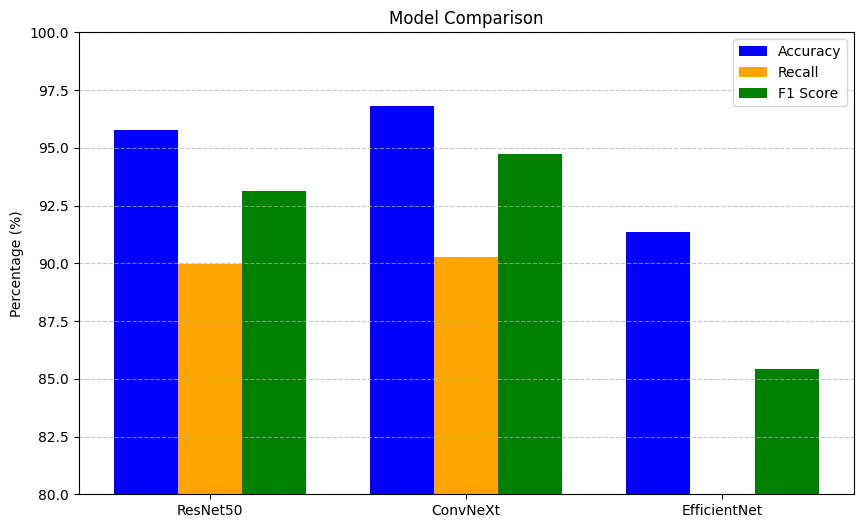

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(models_names))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, accuracy, width, label='Accuracy', color='blue')
plt.bar(x, recall, width, label='Recall', color='orange')
plt.bar(x + width, f1, width, label='F1 Score', color='green')

plt.xticks(x, models_names)
plt.ylabel("Percentage (%)")
plt.ylim(80, 100)
plt.title("Model Comparison")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


ResNet50
Confusion Matrix:
[[716  11]
 [ 34 305]]

Classification Report:
              precision    recall  f1-score   support

         ALL       0.95      0.98      0.97       727
         HEM       0.97      0.90      0.93       339

    accuracy                           0.96      1066
   macro avg       0.96      0.94      0.95      1066
weighted avg       0.96      0.96      0.96      1066


ConvNeXt
Confusion Matrix:
[[726   1]
 [ 33 306]]

Classification Report:
              precision    recall  f1-score   support

         ALL       0.96      1.00      0.98       727
         HEM       1.00      0.90      0.95       339

    accuracy                           0.97      1066
   macro avg       0.98      0.95      0.96      1066
weighted avg       0.97      0.97      0.97      1066


EfficientNet
Confusion Matrix:
[[704  23]
 [ 69 270]]

Classification Report:
              precision    recall  f1-score   support

         ALL       0.91      0.97      0.94       727
        

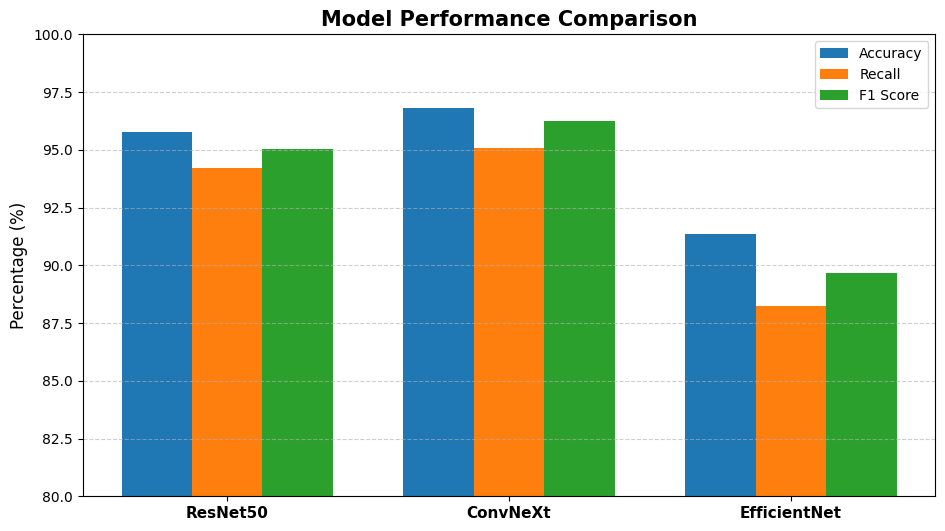

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

def get_metrics(model, loader, model_name):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_true = np.array(all_true)

    acc = accuracy_score(all_true, all_preds)
    recall = recall_score(all_true, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)

    print("\n" + "="*50)
    print(model_name)
    print("="*50)
    print("Confusion Matrix:")
    print(confusion_matrix(all_true, all_preds))
    print("\nClassification Report:")
    print(classification_report(all_true, all_preds, target_names=["ALL", "HEM"], zero_division=0))

    return acc * 100, recall * 100, f1 * 100


model_names = ["ResNet50", "ConvNeXt", "EfficientNet"]

metrics = [
    get_metrics(resnet, val_loader, "ResNet50"),
    get_metrics(convnext_model, val_loader, "ConvNeXt"),
    get_metrics(effnet, val_loader, "EfficientNet")
]

accuracy = [m[0] for m in metrics]
recall = [m[1] for m in metrics]
f1 = [m[2] for m in metrics]


x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1 Score")

plt.xticks(x, model_names, fontsize=11, fontweight="bold")
plt.ylabel("Percentage (%)", fontsize=12)
plt.ylim(80, 100)
plt.title("Model Performance Comparison", fontsize=15, fontweight="bold")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [ ]:
import torch.nn as nn
import torchvision.models as models

regnet = models.regnet_y_16gf(weights=models.RegNet_Y_16GF_Weights.IMAGENET1K_V1)

regnet.fc = nn.Sequential(
    nn.Linear(regnet.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

regnet = regnet.to(device)

Downloading: "https://download.pytorch.org/models/regnet_y_16gf-9e6ed7dd.pth" to /root/.cache/torch/hub/checkpoints/regnet_y_16gf-9e6ed7dd.pth


100%|██████████| 319M/319M [00:08<00:00, 41.0MB/s]


In [ ]:
for param in regnet.parameters():
    param.requires_grad = False

for param in regnet.fc.parameters():
    param.requires_grad = True

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

regnet = models.regnet_y_16gf(weights=models.RegNet_Y_16GF_Weights.IMAGENET1K_V1)

regnet.fc = nn.Sequential(
    nn.Linear(regnet.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

regnet = regnet.to(device)

In [ ]:
from tqdm import tqdm

for param in regnet.parameters():
    param.requires_grad = False

for param in regnet.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    regnet.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 20
best_val_acc = 0

for epoch in range(EPOCHS):
    regnet.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"RegNet Head Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = regnet(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    regnet.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = regnet(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nRegNet Head Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(regnet.state_dict(), "/content/best_regnet_head.pth")
        print("✅ Best RegNet head saved")

RegNet Head Epoch 1/20: 100%|██████████| 67/67 [00:03<00:00, 16.86it/s]



RegNet Head Epoch 1/20
Train Loss: 0.5337
Val Loss: 0.4236
Val Accuracy: 0.8265
✅ Best RegNet head saved


RegNet Head Epoch 2/20: 100%|██████████| 67/67 [00:03<00:00, 17.03it/s]



RegNet Head Epoch 2/20
Train Loss: 0.4001
Val Loss: 0.3696
Val Accuracy: 0.8424
✅ Best RegNet head saved


RegNet Head Epoch 3/20: 100%|██████████| 67/67 [00:03<00:00, 16.92it/s]


...


RegNet Head Epoch 18/20
Train Loss: 0.2984
Val Loss: 0.3029
Val Accuracy: 0.8687


RegNet Head Epoch 19/20: 100%|██████████| 67/67 [00:03<00:00, 17.10it/s]



RegNet Head Epoch 19/20
Train Loss: 0.2952
Val Loss: 0.3021
Val Accuracy: 0.8715


RegNet Head Epoch 20/20: 100%|██████████| 67/67 [00:03<00:00, 16.89it/s]



RegNet Head Epoch 20/20
Train Loss: 0.3008
Val Loss: 0.2992
Val Accuracy: 0.8724


In [ ]:
for param in regnet.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    regnet.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

EPOCHS = 40
best_val_acc = 0
patience = 4
patience_counter = 0

for epoch in range(EPOCHS):
    regnet.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"RegNet FineTune Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = regnet(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    regnet.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = regnet(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nRegNet FineTune Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(regnet.state_dict(), "/content/best_regnet_final.pth")
        print("✅ Best RegNet final saved")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("🛑 Early stopping triggered")
            break

RegNet FineTune Epoch 1/40: 100%|██████████| 67/67 [00:12<00:00,  5.35it/s]



RegNet FineTune Epoch 1/40
Train Loss: 0.2604
Val Loss: 0.2402
Val Accuracy: 0.9099
✅ Best RegNet final saved


RegNet FineTune Epoch 2/40: 100%|██████████| 67/67 [00:12<00:00,  5.34it/s]



RegNet FineTune Epoch 2/40
Train Loss: 0.1879
Val Loss: 0.2083
Val Accuracy: 0.9287
✅ Best RegNet final saved


RegNet FineTune Epoch 3/40: 100%|██████████| 67/67 [00:12<00:00,  5.36it/s]


...


RegNet FineTune Epoch 16/40
Train Loss: 0.0411
Val Loss: 0.1856
Val Accuracy: 0.9400
⚠️ No improvement. Patience: 2/4


RegNet FineTune Epoch 17/40: 100%|██████████| 67/67 [00:12<00:00,  5.36it/s]



RegNet FineTune Epoch 17/40
Train Loss: 0.0355
Val Loss: 0.1867
Val Accuracy: 0.9418
⚠️ No improvement. Patience: 3/4


RegNet FineTune Epoch 18/40: 100%|██████████| 67/67 [00:12<00:00,  5.35it/s]



RegNet FineTune Epoch 18/40
Train Loss: 0.0384
Val Loss: 0.2473
Val Accuracy: 0.9371
⚠️ No improvement. Patience: 4/4
🛑 Early stopping triggered


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

regnet.load_state_dict(torch.load("/content/best_regnet_final.pth"))
regnet = regnet.to(device)
regnet.eval()

tta_transforms = [
    eval_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(5, 5)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(-5, -5)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
]

class BloodDatasetTTA(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        return img, self.labels[idx]

all_tta_probs = []
true_labels = None

for tfm in tta_transforms:
    dataset = BloodDatasetTTA(val_paths, val_labels, tfm)
    loader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

    probs_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)

            outputs = regnet(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            probs_list.extend(probs.cpu().numpy())
            labels_list.extend(labels.numpy())

    all_tta_probs.append(np.array(probs_list))

    if true_labels is None:
        true_labels = np.array(labels_list)

avg_probs = np.mean(all_tta_probs, axis=0)

best_acc = 0
best_threshold = 0.5

for threshold in np.arange(0.20, 0.81, 0.001):
    preds = (avg_probs >= threshold).astype(int)
    acc = accuracy_score(true_labels, preds)

    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

print("Best RegNet TTA Threshold:", best_threshold)
print("Best RegNet TTA Val Accuracy:", best_acc)

final_preds = (avg_probs >= best_threshold).astype(int)

print(confusion_matrix(true_labels, final_preds))
print(classification_report(true_labels, final_preds, target_names=["ALL", "HEM"]))

Best RegNet TTA Threshold: 0.4320000000000002
Best RegNet TTA Val Accuracy: 0.9559099437148217
[[711  16]
 [ 31 308]]
              precision    recall  f1-score   support

         ALL       0.96      0.98      0.97       727
         HEM       0.95      0.91      0.93       339

    accuracy                           0.96      1066
   macro avg       0.95      0.94      0.95      1066
weighted avg       0.96      0.96      0.96      1066



In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

regnet2 = models.regnet_x_16gf(weights=models.RegNet_X_16GF_Weights.IMAGENET1K_V1)

regnet2.fc = nn.Sequential(
    nn.Linear(regnet2.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

regnet2 = regnet2.to(device)

Downloading: "https://download.pytorch.org/models/regnet_x_16gf-2007eb11.pth" to /root/.cache/torch/hub/checkpoints/regnet_x_16gf-2007eb11.pth


100%|██████████| 208M/208M [00:05<00:00, 37.1MB/s]


In [ ]:
for param in regnet2.parameters():
    param.requires_grad = False

for param in regnet2.fc.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.AdamW(regnet2.fc.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 20

In [ ]:
for param in regnet2.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(regnet2.parameters(), lr=1e-5, weight_decay=1e-4)
EPOCHS = 40

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm

regnet2 = models.regnet_x_16gf(weights=models.RegNet_X_16GF_Weights.IMAGENET1K_V1)

regnet2.fc = nn.Sequential(
    nn.Linear(regnet2.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)
)

regnet2 = regnet2.to(device)

In [ ]:
for param in regnet2.parameters():
    param.requires_grad = False

for param in regnet2.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    regnet2.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 20
best_val_acc = 0

for epoch in range(EPOCHS):
    regnet2.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"RegNet-X Head Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = regnet2(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    regnet2.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = regnet2(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nRegNet-X Head Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(regnet2.state_dict(), "/content/best_regnet_x_head.pth")
        print("✅ Best RegNet-X head saved")

RegNet-X Head Epoch 1/20: 100%|██████████| 67/67 [00:03<00:00, 18.60it/s]



RegNet-X Head Epoch 1/20
Train Loss: 0.5464
Val Loss: 0.4388
Val Accuracy: 0.8236
✅ Best RegNet-X head saved


RegNet-X Head Epoch 2/20: 100%|██████████| 67/67 [00:03<00:00, 18.62it/s]



RegNet-X Head Epoch 2/20
Train Loss: 0.4191
Val Loss: 0.3864
Val Accuracy: 0.8537
✅ Best RegNet-X head saved


RegNet-X Head Epoch 3/20: 100%|██████████| 67/67 [00:03<00:00, 18.74it/s]


...


RegNet-X Head Epoch 18/20
Train Loss: 0.3270
Val Loss: 0.3228
Val Accuracy: 0.8780


RegNet-X Head Epoch 19/20: 100%|██████████| 67/67 [00:03<00:00, 18.50it/s]



RegNet-X Head Epoch 19/20
Train Loss: 0.3181
Val Loss: 0.3226
Val Accuracy: 0.8734


RegNet-X Head Epoch 20/20: 100%|██████████| 67/67 [00:03<00:00, 18.36it/s]



RegNet-X Head Epoch 20/20
Train Loss: 0.3191
Val Loss: 0.3219
Val Accuracy: 0.8780


In [ ]:
regnet2.load_state_dict(torch.load("/content/best_regnet_x_head.pth"))

for param in regnet2.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    regnet2.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

EPOCHS = 40
best_val_acc = 0
patience = 6
patience_counter = 0

for epoch in range(EPOCHS):
    regnet2.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"RegNet-X FineTune Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = regnet2(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    regnet2.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = regnet2(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nRegNet-X FineTune Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(regnet2.state_dict(), "/content/best_regnet_x_final.pth")
        print("✅ Best RegNet-X final saved")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("🛑 Early stopping triggered")
            break

RegNet-X FineTune Epoch 1/40: 100%|██████████| 67/67 [00:11<00:00,  5.89it/s]



RegNet-X FineTune Epoch 1/40
Train Loss: 0.2953
Val Loss: 0.2683
Val Accuracy: 0.8959
✅ Best RegNet-X final saved


RegNet-X FineTune Epoch 2/40: 100%|██████████| 67/67 [00:11<00:00,  5.91it/s]



RegNet-X FineTune Epoch 2/40
Train Loss: 0.2371
Val Loss: 0.2285
Val Accuracy: 0.9174
✅ Best RegNet-X final saved


RegNet-X FineTune Epoch 3/40: 100%|██████████| 67/67 [00:11<00:00,  5.91it/s]


...


RegNet-X FineTune Epoch 16/40
Train Loss: 0.0357
Val Loss: 0.1523
Val Accuracy: 0.9493
⚠️ No improvement. Patience: 4/6


RegNet-X FineTune Epoch 17/40: 100%|██████████| 67/67 [00:11<00:00,  5.90it/s]



RegNet-X FineTune Epoch 17/40
Train Loss: 0.0355
Val Loss: 0.1509
Val Accuracy: 0.9475
⚠️ No improvement. Patience: 5/6


RegNet-X FineTune Epoch 18/40: 100%|██████████| 67/67 [00:11<00:00,  5.89it/s]



RegNet-X FineTune Epoch 18/40
Train Loss: 0.0313
Val Loss: 0.1504
Val Accuracy: 0.9475
⚠️ No improvement. Patience: 6/6
🛑 Early stopping triggered


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

regnet2.load_state_dict(torch.load("/content/best_regnet_x_final.pth"))
regnet2.eval()

tta_transforms = [
    eval_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(5, 5)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(-5, -5)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
]

class BloodDatasetTTA(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        return img, self.labels[idx]


all_tta_probs = []
true_labels = None

for tfm in tta_transforms:
    dataset = BloodDatasetTTA(val_paths, val_labels, tfm)
    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    probs_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)

            outputs = regnet2(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            probs_list.extend(probs.cpu().numpy())
            labels_list.extend(labels.numpy())

    all_tta_probs.append(np.array(probs_list))

    if true_labels is None:
        true_labels = np.array(labels_list)

avg_probs = np.mean(all_tta_probs, axis=0)

best_acc = 0
best_threshold = 0.5

for threshold in np.arange(0.20, 0.81, 0.001):
    preds = (avg_probs >= threshold).astype(int)
    acc = accuracy_score(true_labels, preds)

    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

print("Best RegNet-X TTA Threshold:", best_threshold)
print("Best RegNet-X TTA Val Accuracy:", best_acc)

final_preds = (avg_probs >= best_threshold).astype(int)

print(confusion_matrix(true_labels, final_preds))
print(classification_report(true_labels, final_preds, target_names=["ALL", "HEM"]))

Best RegNet-X TTA Threshold: 0.48400000000000026
Best RegNet-X TTA Val Accuracy: 0.9624765478424016
[[717  10]
 [ 30 309]]
              precision    recall  f1-score   support

         ALL       0.96      0.99      0.97       727
         HEM       0.97      0.91      0.94       339

    accuracy                           0.96      1066
   macro avg       0.96      0.95      0.96      1066
weighted avg       0.96      0.96      0.96      1066



In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn

regnet2.load_state_dict(torch.load("/content/best_regnet_x_final.pth"))
regnet2 = regnet2.to(device)

for param in regnet2.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    regnet2.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 40
best_val_acc = 0

for epoch in range(EPOCHS):
    regnet2.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"RegNet-X Epoch {epoch+1}/40"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = regnet2(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(regnet2.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    regnet2.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = regnet2(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nEpoch {epoch+1}/40")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(regnet2.state_dict(), "/content/best_regnet_x_40ep.pth")
        print("✅ Best RegNet-X 40ep model saved")

RegNet-X Epoch 1/40: 100%|██████████| 67/67 [00:11<00:00,  5.86it/s]



Epoch 1/40
Train Loss: 0.2879
Val Loss: 0.3123
Val Accuracy: 0.9409
✅ Best RegNet-X 40ep model saved


RegNet-X Epoch 2/40: 100%|██████████| 67/67 [00:11<00:00,  5.88it/s]



Epoch 2/40
Train Loss: 0.2543
Val Loss: 0.2987
Val Accuracy: 0.9493
✅ Best RegNet-X 40ep model saved


RegNet-X Epoch 3/40: 100%|██████████| 67/67 [00:11<00:00,  5.88it/s]


...


Epoch 38/40
Train Loss: 0.2125
Val Loss: 0.2565
Val Accuracy: 0.9700


RegNet-X Epoch 39/40: 100%|██████████| 67/67 [00:11<00:00,  5.87it/s]



Epoch 39/40
Train Loss: 0.2123
Val Loss: 0.2566
Val Accuracy: 0.9690


RegNet-X Epoch 40/40: 100%|██████████| 67/67 [00:11<00:00,  5.88it/s]



Epoch 40/40
Train Loss: 0.2122
Val Loss: 0.2578
Val Accuracy: 0.9690


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

regnet2.load_state_dict(torch.load("/content/best_regnet_x_40ep.pth"))
regnet2.eval()

normalize = transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])

tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        normalize
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        normalize
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        normalize
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(5, 5)),
        transforms.ToTensor(),
        normalize
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(-5, -5)),
        transforms.ToTensor(),
        normalize
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
        transforms.ToTensor(),
        normalize
    ]),
]

class BloodDatasetTTA(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        return img, self.labels[idx]


all_tta_probs = []
true_labels = None

for tfm in tta_transforms:
    dataset = BloodDatasetTTA(val_paths, val_labels, tfm)
    loader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

    probs_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)

            outputs = regnet2(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            probs_list.extend(probs.cpu().numpy())
            labels_list.extend(labels.numpy())

    all_tta_probs.append(np.array(probs_list))

    if true_labels is None:
        true_labels = np.array(labels_list)

avg_probs = np.mean(all_tta_probs, axis=0)

best_acc = 0
best_threshold = 0.5

for threshold in np.arange(0.20, 0.81, 0.001):
    preds = (avg_probs >= threshold).astype(int)
    acc = accuracy_score(true_labels, preds)

    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

print("Best RegNet-X 40ep TTA Threshold:", best_threshold)
print("Best RegNet-X 40ep TTA Val Accuracy:", best_acc)

final_preds = (avg_probs >= best_threshold).astype(int)

print(confusion_matrix(true_labels, final_preds))
print(classification_report(true_labels, final_preds, target_names=["ALL", "HEM"]))

Best RegNet-X 40ep TTA Threshold: 0.3160000000000001
Best RegNet-X 40ep TTA Val Accuracy: 0.9793621013133208
[[722   5]
 [ 17 322]]
              precision    recall  f1-score   support

         ALL       0.98      0.99      0.98       727
         HEM       0.98      0.95      0.97       339

    accuracy                           0.98      1066
   macro avg       0.98      0.97      0.98      1066
weighted avg       0.98      0.98      0.98      1066



In [ ]:
import pandas as pd

results = [
    {
        "Model": "ResNet50 ",
        "Accuracy": 96.62,
        "Recall": 98.00,
        "F1 Score": 97.00
    },
    {
        "Model": "ConvNeXt ",
        "Accuracy": 96.90,
        "Recall": 95.00,
        "F1 Score": 96.00
    },
    {
        "Model": "EfficientNet-B3",
        "Accuracy": 91.56,
        "Recall": 88.00,
        "F1 Score": 90.00
    },

    {
        "Model": "RegNet-X + TTA",
        "Accuracy": 97.94,
        "Recall": 99.00,
        "F1 Score": 98.00
    }
]

results_df = pd.DataFrame(results)
results_df.to_csv("/content/model_results_summary.csv", index=False)

results_df

,Model,Accuracy,Recall,F1 Score
0,ResNet50,96.62,98.0,97.0
1,ConvNeXt,96.90,95.0,96.0
2,EfficientNet-B3,91.56,88.0,90.0
3,RegNet-X + TTA,97.94,99.0,98.0


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm

vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

vgg.classifier[6] = nn.Linear(4096, 2)

vgg = vgg.to(device)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 254MB/s]


In [ ]:
for param in vgg.features.parameters():
    param.requires_grad = False

for param in vgg.classifier.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    vgg.classifier.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 5
best_val_acc = 0

for epoch in range(EPOCHS):
    vgg.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"VGG19 Head Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = vgg(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    vgg.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = vgg(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nVGG19 Head Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(vgg.state_dict(), "/content/best_vgg19_head.pth")
        print("✅ Best VGG19 head saved")

VGG19 Head Epoch 1/5: 100%|██████████| 67/67 [00:04<00:00, 16.19it/s]



VGG19 Head Epoch 1/5
Train Loss: 0.4834
Val Loss: 0.4376
Val Accuracy: 0.8161
✅ Best VGG19 head saved


VGG19 Head Epoch 2/5: 100%|██████████| 67/67 [00:04<00:00, 16.32it/s]



VGG19 Head Epoch 2/5
Train Loss: 0.4241
Val Loss: 0.4240
Val Accuracy: 0.8265
✅ Best VGG19 head saved


VGG19 Head Epoch 3/5: 100%|██████████| 67/67 [00:04<00:00, 16.09it/s]



VGG19 Head Epoch 3/5
Train Loss: 0.4084
Val Loss: 0.4183
Val Accuracy: 0.8293
✅ Best VGG19 head saved


VGG19 Head Epoch 4/5: 100%|██████████| 67/67 [00:04<00:00, 16.28it/s]



VGG19 Head Epoch 4/5
Train Loss: 0.4017
Val Loss: 0.4075
Val Accuracy: 0.8302
✅ Best VGG19 head saved


VGG19 Head Epoch 5/5: 100%|██████████| 67/67 [00:04<00:00, 16.39it/s]



VGG19 Head Epoch 5/5
Train Loss: 0.4016
Val Loss: 0.4120
Val Accuracy: 0.8255


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm

vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

vgg.classifier[6] = nn.Linear(4096, 2)

vgg = vgg.to(device)

In [ ]:
for param in vgg.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    vgg.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 40
best_val_acc = 0

for epoch in range(EPOCHS):
    vgg.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"VGG19 Epoch {epoch+1}/40"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = vgg(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(vgg.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    vgg.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = vgg(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nVGG19 Epoch {epoch+1}/40")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(vgg.state_dict(), "/content/best_vgg19_40ep.pth")
        print("✅ Best VGG19 model saved")

VGG19 Epoch 1/40: 100%|██████████| 67/67 [00:09<00:00,  7.15it/s]



VGG19 Epoch 1/40
Train Loss: 0.5034
Val Loss: 0.4600
Val Accuracy: 0.8068
✅ Best VGG19 model saved


VGG19 Epoch 2/40: 100%|██████████| 67/67 [00:09<00:00,  7.16it/s]



VGG19 Epoch 2/40
Train Loss: 0.3860
Val Loss: 0.3826
Val Accuracy: 0.8452
✅ Best VGG19 model saved


VGG19 Epoch 3/40: 100%|██████████| 67/67 [00:09<00:00,  7.12it/s]


...


VGG19 Epoch 38/40
Train Loss: 0.0326
Val Loss: 0.2633
Val Accuracy: 0.9409


VGG19 Epoch 39/40: 100%|██████████| 67/67 [00:09<00:00,  7.12it/s]



VGG19 Epoch 39/40
Train Loss: 0.0327
Val Loss: 0.2664
Val Accuracy: 0.9409


VGG19 Epoch 40/40: 100%|██████████| 67/67 [00:09<00:00,  7.13it/s]



VGG19 Epoch 40/40
Train Loss: 0.0350
Val Loss: 0.2639
Val Accuracy: 0.9409


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

vgg.load_state_dict(torch.load("/content/best_vgg19_40ep.pth"))
vgg = vgg.to(device)
vgg.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)

        outputs = vgg(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

acc = accuracy_score(all_true, all_preds)
precision = precision_score(all_true, all_preds, average="macro", zero_division=0)
recall = recall_score(all_true, all_preds, average="macro", zero_division=0)
f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)

print("\n========== VGG19 RESULTS ==========")

print("\nConfusion Matrix:")
print(confusion_matrix(all_true, all_preds))

print("\nMetrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(all_true, all_preds, target_names=["ALL", "HEM"], zero_division=0))


========== VGG19 RESULTS ==========

Confusion Matrix:
[[706  21]
 [ 41 298]]

Metrics:
Accuracy : 0.9418
Precision: 0.9396
Recall   : 0.9251
F1-score : 0.9319

Detailed Classification Report:
              precision    recall  f1-score   support

         ALL       0.95      0.97      0.96       727
         HEM       0.93      0.88      0.91       339

    accuracy                           0.94      1066
   macro avg       0.94      0.93      0.93      1066
weighted avg       0.94      0.94      0.94      1066



In [ ]:
recall_score(all_true, all_preds, pos_label=0)

0.9711141678129298

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm

alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

alexnet.classifier[6] = nn.Linear(4096, 2)

alexnet = alexnet.to(device)

for param in alexnet.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    alexnet.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 40
best_val_acc = 0

for epoch in range(EPOCHS):
    alexnet.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"AlexNet Epoch {epoch+1}/40"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = alexnet(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(alexnet.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    alexnet.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = alexnet(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nAlexNet Epoch {epoch+1}/40")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(alexnet.state_dict(), "/content/best_alexnet_40ep.pth")
        print("✅ Best AlexNet model saved")

AlexNet Epoch 1/40:  49%|████▉     | 33/67 [00:01<00:01, 20.87it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bd4d4ab0ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7bd4d4ab0ae0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader


AlexNet Epoch 1/40
Train Loss: 0.5186
Val Loss: 0.4622
Val Accuracy: 0.7824
✅ Best AlexNet model saved


AlexNet Epoch 2/40:  43%|████▎     | 29/67 [00:01<00:01, 20.22it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bd4d4ab0ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7bd4d4ab0ae0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    
self._shutdown_workers()  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
assert self._parent_pid == os.getpid(), 'can only test a child proces


AlexNet Epoch 2/40
Train Loss: 0.4386
Val Loss: 0.4395
Val Accuracy: 0.8058
✅ Best AlexNet model saved


AlexNet Epoch 3/40:  25%|██▌       | 17/67 [00:01<00:02, 18.05it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bd4d4ab0ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bd4d4ab0ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/li

...


AlexNet Epoch 38/40
Train Loss: 0.2256
Val Loss: 0.2630
Val Accuracy: 0.9071
✅ Best AlexNet model saved


AlexNet Epoch 39/40: 100%|██████████| 67/67 [00:03<00:00, 19.15it/s]



AlexNet Epoch 39/40
Train Loss: 0.2277
Val Loss: 0.2630
Val Accuracy: 0.9071


AlexNet Epoch 40/40: 100%|██████████| 67/67 [00:03<00:00, 19.27it/s]



AlexNet Epoch 40/40
Train Loss: 0.2242
Val Loss: 0.2630
Val Accuracy: 0.9071


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


alexnet.load_state_dict(torch.load("/content/best_alexnet_40ep.pth"))
alexnet = alexnet.to(device)
alexnet.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)

        outputs = alexnet(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

acc = accuracy_score(all_true, all_preds)
precision = precision_score(all_true, all_preds, average="macro", zero_division=0)
recall = recall_score(all_true, all_preds, average="macro", zero_division=0)
f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)

print("\n========== AlexNet RESULTS ==========")

print("\nConfusion Matrix:")
print(confusion_matrix(all_true, all_preds))

print("\nMetrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(all_true, all_preds, target_names=["ALL", "HEM"], zero_division=0))


========== AlexNet RESULTS ==========

Confusion Matrix:
[[695  32]
 [ 67 272]]

Metrics:
Accuracy : 0.9071
Precision: 0.9034
Recall   : 0.8792
F1-score : 0.8898

Detailed Classification Report:
              precision    recall  f1-score   support

         ALL       0.91      0.96      0.93       727
         HEM       0.89      0.80      0.85       339

    accuracy                           0.91      1066
   macro avg       0.90      0.88      0.89      1066
weighted avg       0.91      0.91      0.91      1066



In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm

inception = models.inception_v3(
    weights=models.Inception_V3_Weights.IMAGENET1K_V1,
    aux_logits=True
)

inception.fc = nn.Linear(inception.fc.in_features, 2)

if inception.AuxLogits is not None:
    inception.AuxLogits.fc = nn.Linear(inception.AuxLogits.fc.in_features, 2)

inception = inception.to(device)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 163MB/s] 


In [ ]:
inception_train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

inception_eval_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
inception_train_dataset = BloodDataset(train_paths, train_labels, inception_train_transform)
inception_val_dataset = BloodDataset(val_paths, val_labels, inception_eval_transform)

inception_train_loader = DataLoader(
    inception_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

inception_val_loader = DataLoader(
    inception_val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

inception_train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

inception_eval_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

inception_train_dataset = BloodDataset(train_paths, train_labels, inception_train_transform)
inception_val_dataset = BloodDataset(val_paths, val_labels, inception_eval_transform)

inception_train_loader = DataLoader(
    inception_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

inception_val_loader = DataLoader(
    inception_val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm

inception = models.inception_v3(
    weights=models.Inception_V3_Weights.IMAGENET1K_V1,
    aux_logits=True
)

inception.fc = nn.Linear(inception.fc.in_features, 2)

if inception.AuxLogits is not None:
    inception.AuxLogits.fc = nn.Linear(inception.AuxLogits.fc.in_features, 2)

inception = inception.to(device)

In [ ]:
for param in inception.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    inception.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 40
best_val_acc = 0

for epoch in range(EPOCHS):
    inception.train()
    train_loss = 0.0

    for images, labels in tqdm(inception_train_loader, desc=f"InceptionV3 Epoch {epoch+1}/40"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = inception(images)

            if hasattr(outputs, "logits") and hasattr(outputs, "aux_logits"):
                main_out = outputs.logits
                aux_out = outputs.aux_logits
                loss = criterion(main_out, labels) + 0.4 * criterion(aux_out, labels)
            else:
                loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(inception.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    inception.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in inception_val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = inception(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nInceptionV3 Epoch {epoch+1}/40")
    print(f"Train Loss: {train_loss / len(inception_train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(inception_val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(inception.state_dict(), "/content/best_inceptionv3_40ep.pth")
        print("✅ Best InceptionV3 model saved")

InceptionV3 Epoch 1/40: 100%|██████████| 134/134 [00:08<00:00, 15.98it/s]



InceptionV3 Epoch 1/40
Train Loss: 0.6440
Val Loss: 0.3364
Val Accuracy: 0.8621
✅ Best InceptionV3 model saved


InceptionV3 Epoch 2/40: 100%|██████████| 134/134 [00:07<00:00, 16.88it/s]



InceptionV3 Epoch 2/40
Train Loss: 0.4062
Val Loss: 0.2552
Val Accuracy: 0.9015
✅ Best InceptionV3 model saved


InceptionV3 Epoch 3/40: 100%|██████████| 134/134 [00:07<00:00, 16.88it/s]


...


InceptionV3 Epoch 38/40
Train Loss: 0.0182
Val Loss: 0.1603
Val Accuracy: 0.9681


InceptionV3 Epoch 39/40: 100%|██████████| 134/134 [00:07<00:00, 16.93it/s]



InceptionV3 Epoch 39/40
Train Loss: 0.0166
Val Loss: 0.1665
Val Accuracy: 0.9662


InceptionV3 Epoch 40/40: 100%|██████████| 134/134 [00:08<00:00, 16.75it/s]



InceptionV3 Epoch 40/40
Train Loss: 0.0198
Val Loss: 0.1616
Val Accuracy: 0.9681


In [ ]:
set(train_paths) & set(val_paths)

set()

In [ ]:
inception.eval()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Check leakage
overlap = set(train_paths) & set(val_paths)
print("Train/Val overlap:", len(overlap))

# 2. Load best Inception model
inception.load_state_dict(torch.load("/content/best_inceptionv3_40ep.pth"))
inception = inception.to(device)
inception.eval()

# 3. Clean validation evaluation — NO TTA, NO threshold tuning
all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in inception_val_loader:   # important: Inception 299x299 val loader
        images = images.to(device, non_blocking=True)

        outputs = inception(images)

        # In eval mode, Inception should return normal logits
        if hasattr(outputs, "logits"):
            outputs = outputs.logits

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

acc = accuracy_score(all_true, all_preds)
precision = precision_score(all_true, all_preds, average="macro", zero_division=0)
recall = recall_score(all_true, all_preds, average="macro", zero_division=0)
f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)

print("\n========== CLEAN INCEPTIONV3 RESULTS ==========")

print("\nConfusion Matrix:")
print(confusion_matrix(all_true, all_preds))

print("\nMetrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(all_true, all_preds, target_names=["ALL", "HEM"], zero_division=0))

Train/Val overlap: 0

========== CLEAN INCEPTIONV3 RESULTS ==========

Confusion Matrix:
[[718   9]
 [ 25 314]]

Metrics:
Accuracy : 0.9681
Precision: 0.9692
Recall   : 0.9569
F1-score : 0.9628

Detailed Classification Report:
              precision    recall  f1-score   support

         ALL       0.97      0.99      0.98       727
         HEM       0.97      0.93      0.95       339

    accuracy                           0.97      1066
   macro avg       0.97      0.96      0.96      1066
weighted avg       0.97      0.97      0.97      1066



In [ ]:
!pip install timm -q

In [ ]:
import timm
import torch
import torch.nn as nn
from tqdm import tqdm

In [ ]:
xception = timm.create_model("xception", pretrained=True, num_classes=2)
xception = xception.to(device)

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

xception_train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

xception_val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

xception_train_dataset = BloodDataset(train_paths, train_labels, xception_train_transform)
xception_val_dataset = BloodDataset(val_paths, val_labels, xception_val_transform)

xception_train_loader = DataLoader(
    xception_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

xception_val_loader = DataLoader(
    xception_val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [ ]:
for param in xception.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    xception.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 40
best_val_acc = 0

for epoch in range(EPOCHS):
    xception.train()
    train_loss = 0.0

    for images, labels in tqdm(xception_train_loader, desc=f"Xception Epoch {epoch+1}/40"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = xception(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(xception.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    xception.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in xception_val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda"):
                outputs = xception(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nXception Epoch {epoch+1}/40")
    print(f"Train Loss: {train_loss / len(xception_train_loader):.4f}")
    print(f"Val Loss: {val_loss / len(xception_val_loader):.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(xception.state_dict(), "/content/best_xception_40ep.pth")
        print("✅ Best Xception model saved")

Xception Epoch 1/40: 100%|██████████| 134/134 [00:21<00:00,  6.15it/s]



Xception Epoch 1/40
Train Loss: 0.5027
Val Loss: 0.3914
Val Accuracy: 0.8518
✅ Best Xception model saved


Xception Epoch 2/40: 100%|██████████| 134/134 [00:10<00:00, 12.83it/s]



Xception Epoch 2/40
Train Loss: 0.3249
Val Loss: 0.3033
Val Accuracy: 0.8818
✅ Best Xception model saved


Xception Epoch 3/40: 100%|██████████| 134/134 [00:10<00:00, 12.90it/s]


...


Xception Epoch 38/40
Train Loss: 0.0400
Val Loss: 0.1672
Val Accuracy: 0.9465


Xception Epoch 39/40: 100%|██████████| 134/134 [00:10<00:00, 12.90it/s]



Xception Epoch 39/40
Train Loss: 0.0423
Val Loss: 0.1665
Val Accuracy: 0.9512


Xception Epoch 40/40: 100%|██████████| 134/134 [00:10<00:00, 12.89it/s]



Xception Epoch 40/40
Train Loss: 0.0374
Val Loss: 0.1662
Val Accuracy: 0.9540


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

xception.load_state_dict(torch.load("/content/best_xception_40ep.pth"))
xception = xception.to(device)
xception.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in xception_val_loader:
        images = images.to(device, non_blocking=True)

        outputs = xception(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

acc = accuracy_score(all_true, all_preds)
precision = precision_score(all_true, all_preds, average="macro", zero_division=0)
recall = recall_score(all_true, all_preds, average="macro", zero_division=0)
f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)

print("\n========== Xception RESULTS ==========")

print("\nConfusion Matrix:")
print(confusion_matrix(all_true, all_preds))

print("\nMetrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(all_true, all_preds, target_names=["ALL", "HEM"], zero_division=0))


========== Xception RESULTS ==========

Confusion Matrix:
[[715  12]
 [ 35 304]]

Metrics:
Accuracy : 0.9559
Precision: 0.9577
Recall   : 0.9401
F1-score : 0.9482

Detailed Classification Report:
              precision    recall  f1-score   support

         ALL       0.95      0.98      0.97       727
         HEM       0.96      0.90      0.93       339

    accuracy                           0.96      1066
   macro avg       0.96      0.94      0.95      1066
weighted avg       0.96      0.96      0.96      1066



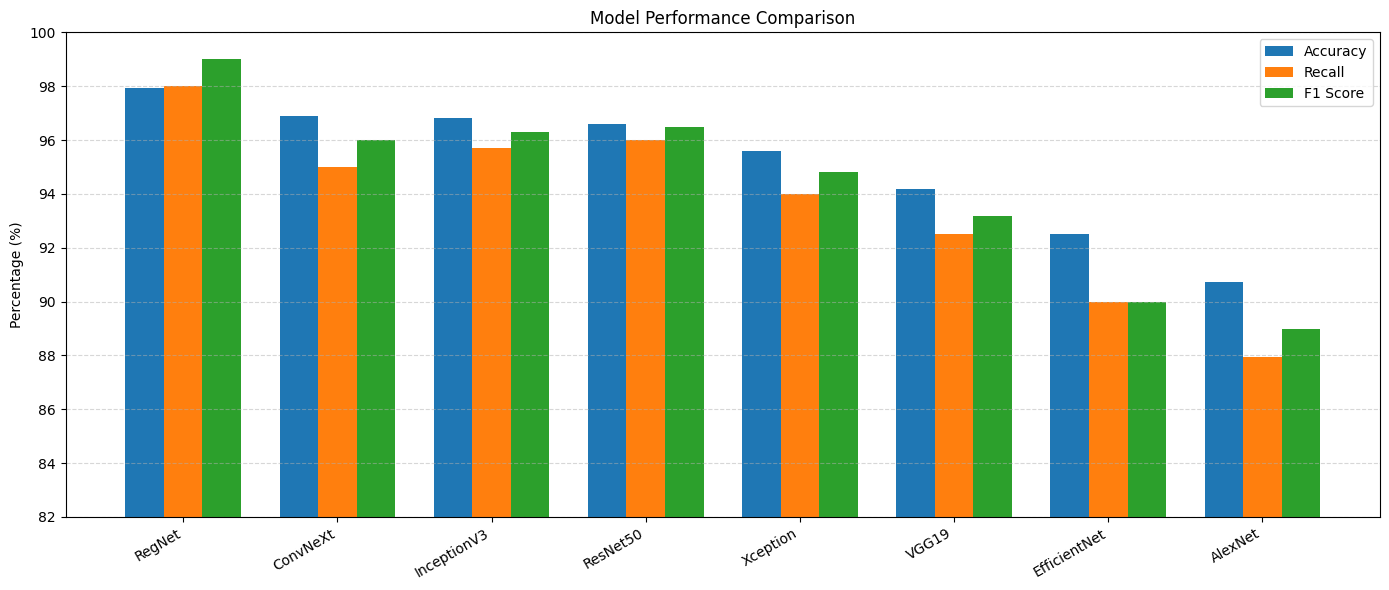

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["RegNet", "ConvNeXt", "InceptionV3", "ResNet50",
           "Xception", "VGG19", "EfficientNet", "AlexNet"]

accuracy = [97.94, 96.9, 96.81, 96.6,  95.59, 94.18, 92.5, 90.71]
recall   = [98.0, 95.0, 95.69, 96.0,  94.01, 92.51, 90.0, 87.92]
f1       = [99.0, 96.0, 96.28, 96.5,  94.82, 93.19, 90.0, 88.98]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(14,6))

plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1 Score")

plt.xticks(x, models, rotation=30, ha='right')
plt.ylabel("Percentage (%)")
plt.title("Model Performance Comparison")

# 🔥 KEY FIX
plt.ylim(82, 100)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

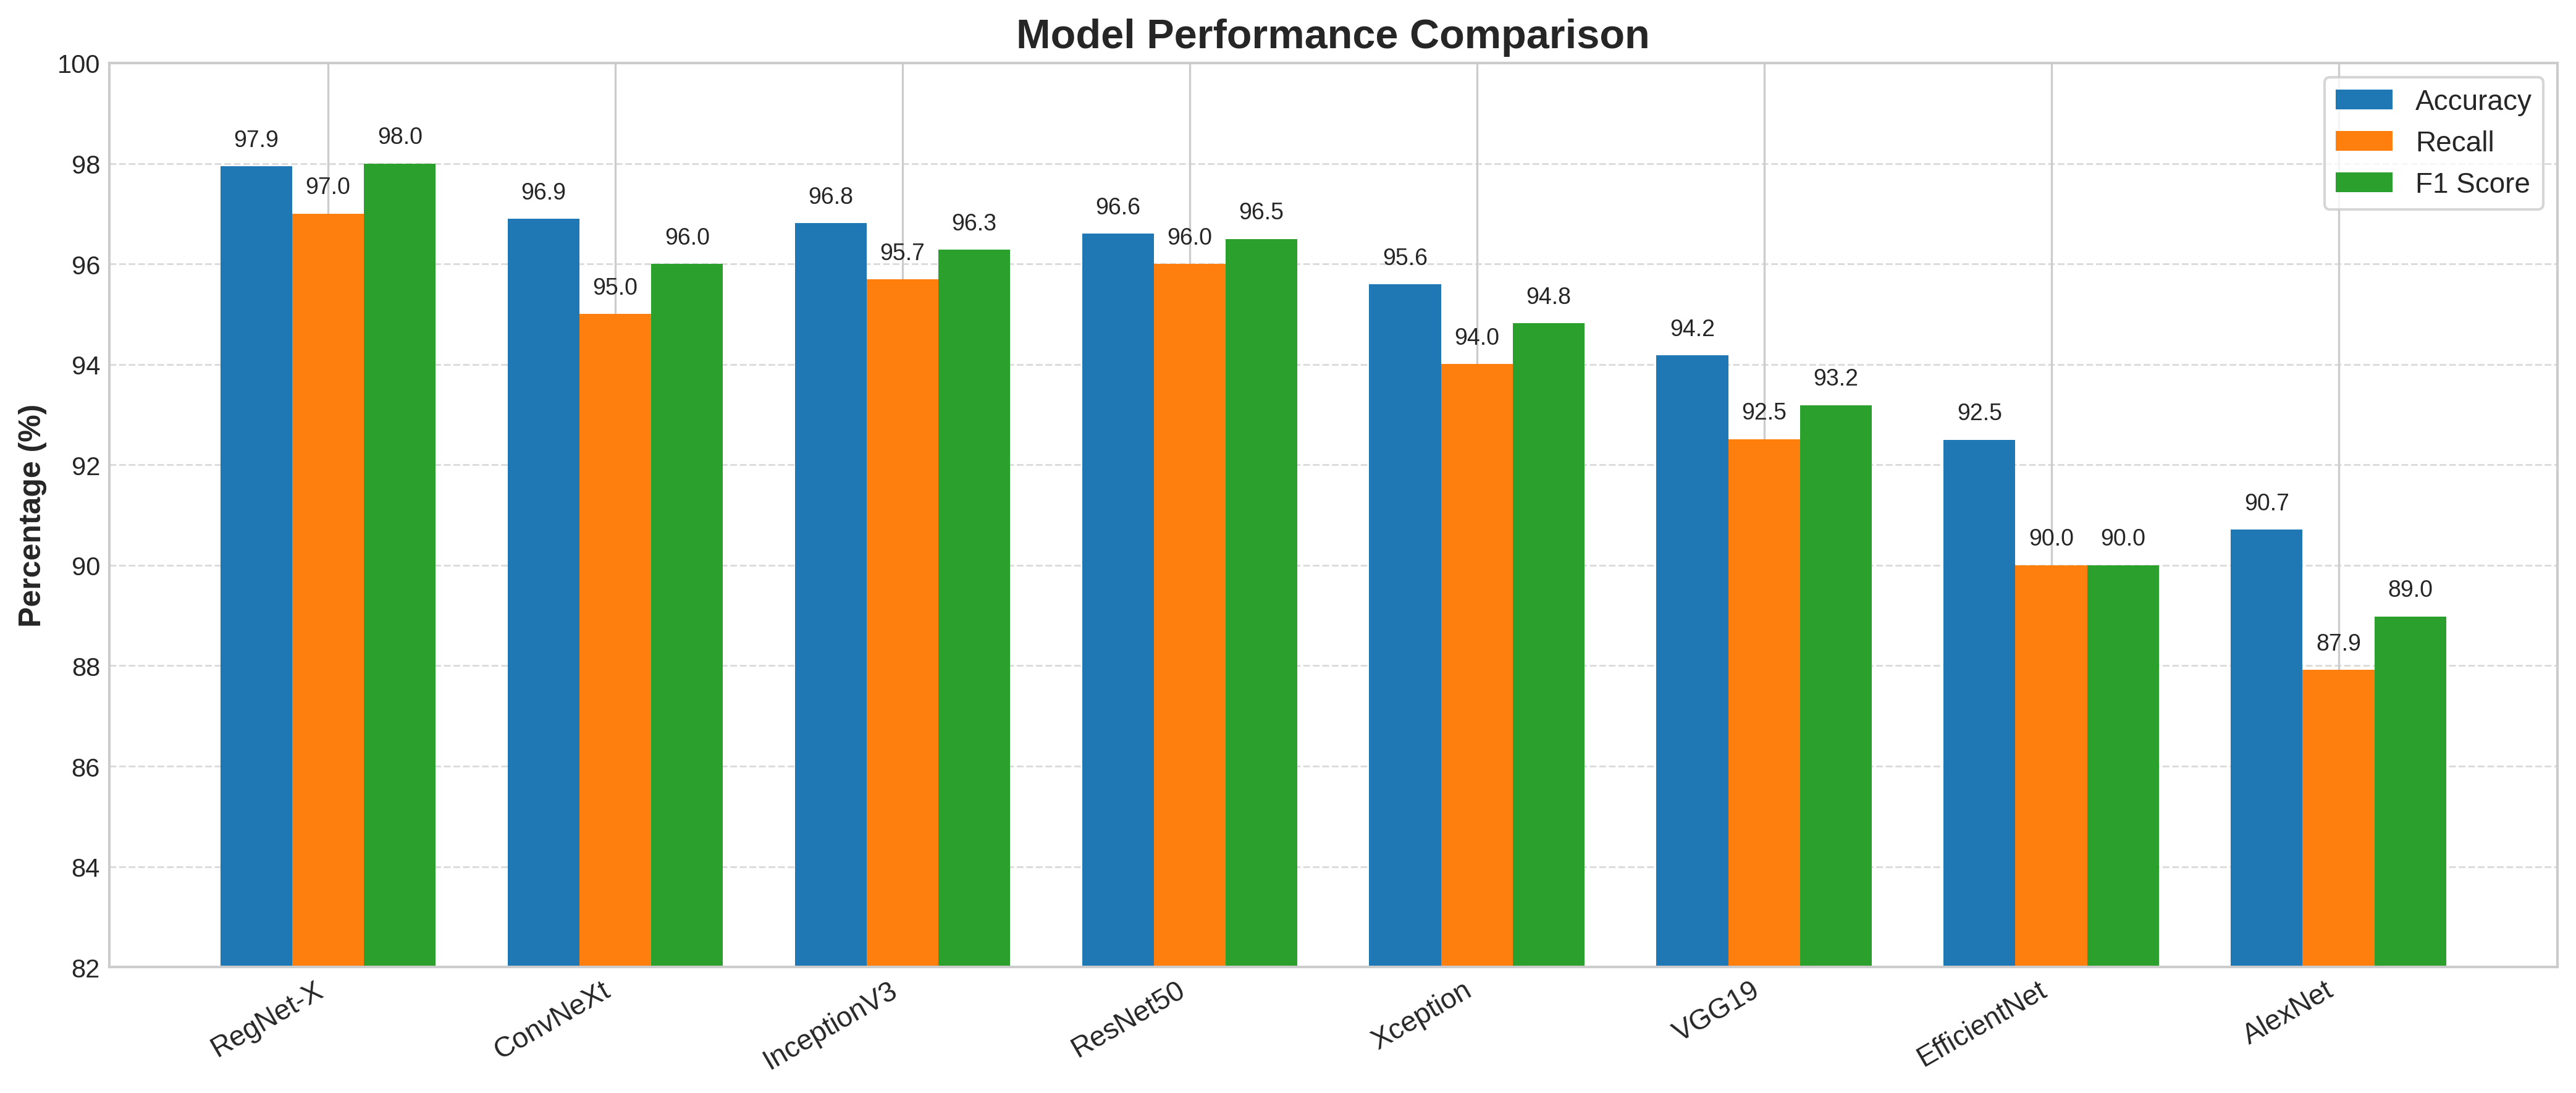

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["RegNet-X", "ConvNeXt", "InceptionV3", "ResNet50",
           "Xception", "VGG19", "EfficientNet", "AlexNet"]

accuracy = [97.94, 96.9, 96.81, 96.6,  95.59, 94.18, 92.5, 90.71]
recall   = [97.0, 95.0, 95.69, 96.0, 94.01, 92.51, 90.0, 87.92]
f1       = [98.0, 96.0, 96.28, 96.5,  94.82, 93.19, 90.0, 88.98]

x = np.arange(len(models))
width = 0.25

# Style
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(14, 6), dpi=300)

# Bars
bars1 = ax.bar(x - width, accuracy, width, label="Accuracy")
bars2 = ax.bar(x, recall, width, label="Recall")
bars3 = ax.bar(x + width, f1, width, label="F1 Score")

# Labels & title
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=11)
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_title("Model Performance Comparison", fontsize=16, fontweight="bold")

# Y-axis zoom (important)
ax.set_ylim(82, 100)
ax.set_yticks(np.arange(82, 101, 2))

# Grid
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Legend
ax.legend(frameon=True, fontsize=11)

# Annotate values on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                height + 0.3,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# Tight layout
plt.tight_layout()

# Save high-quality figure
plt.savefig("model_comparison_high_quality.png", dpi=300, bbox_inches='tight')

plt.show()

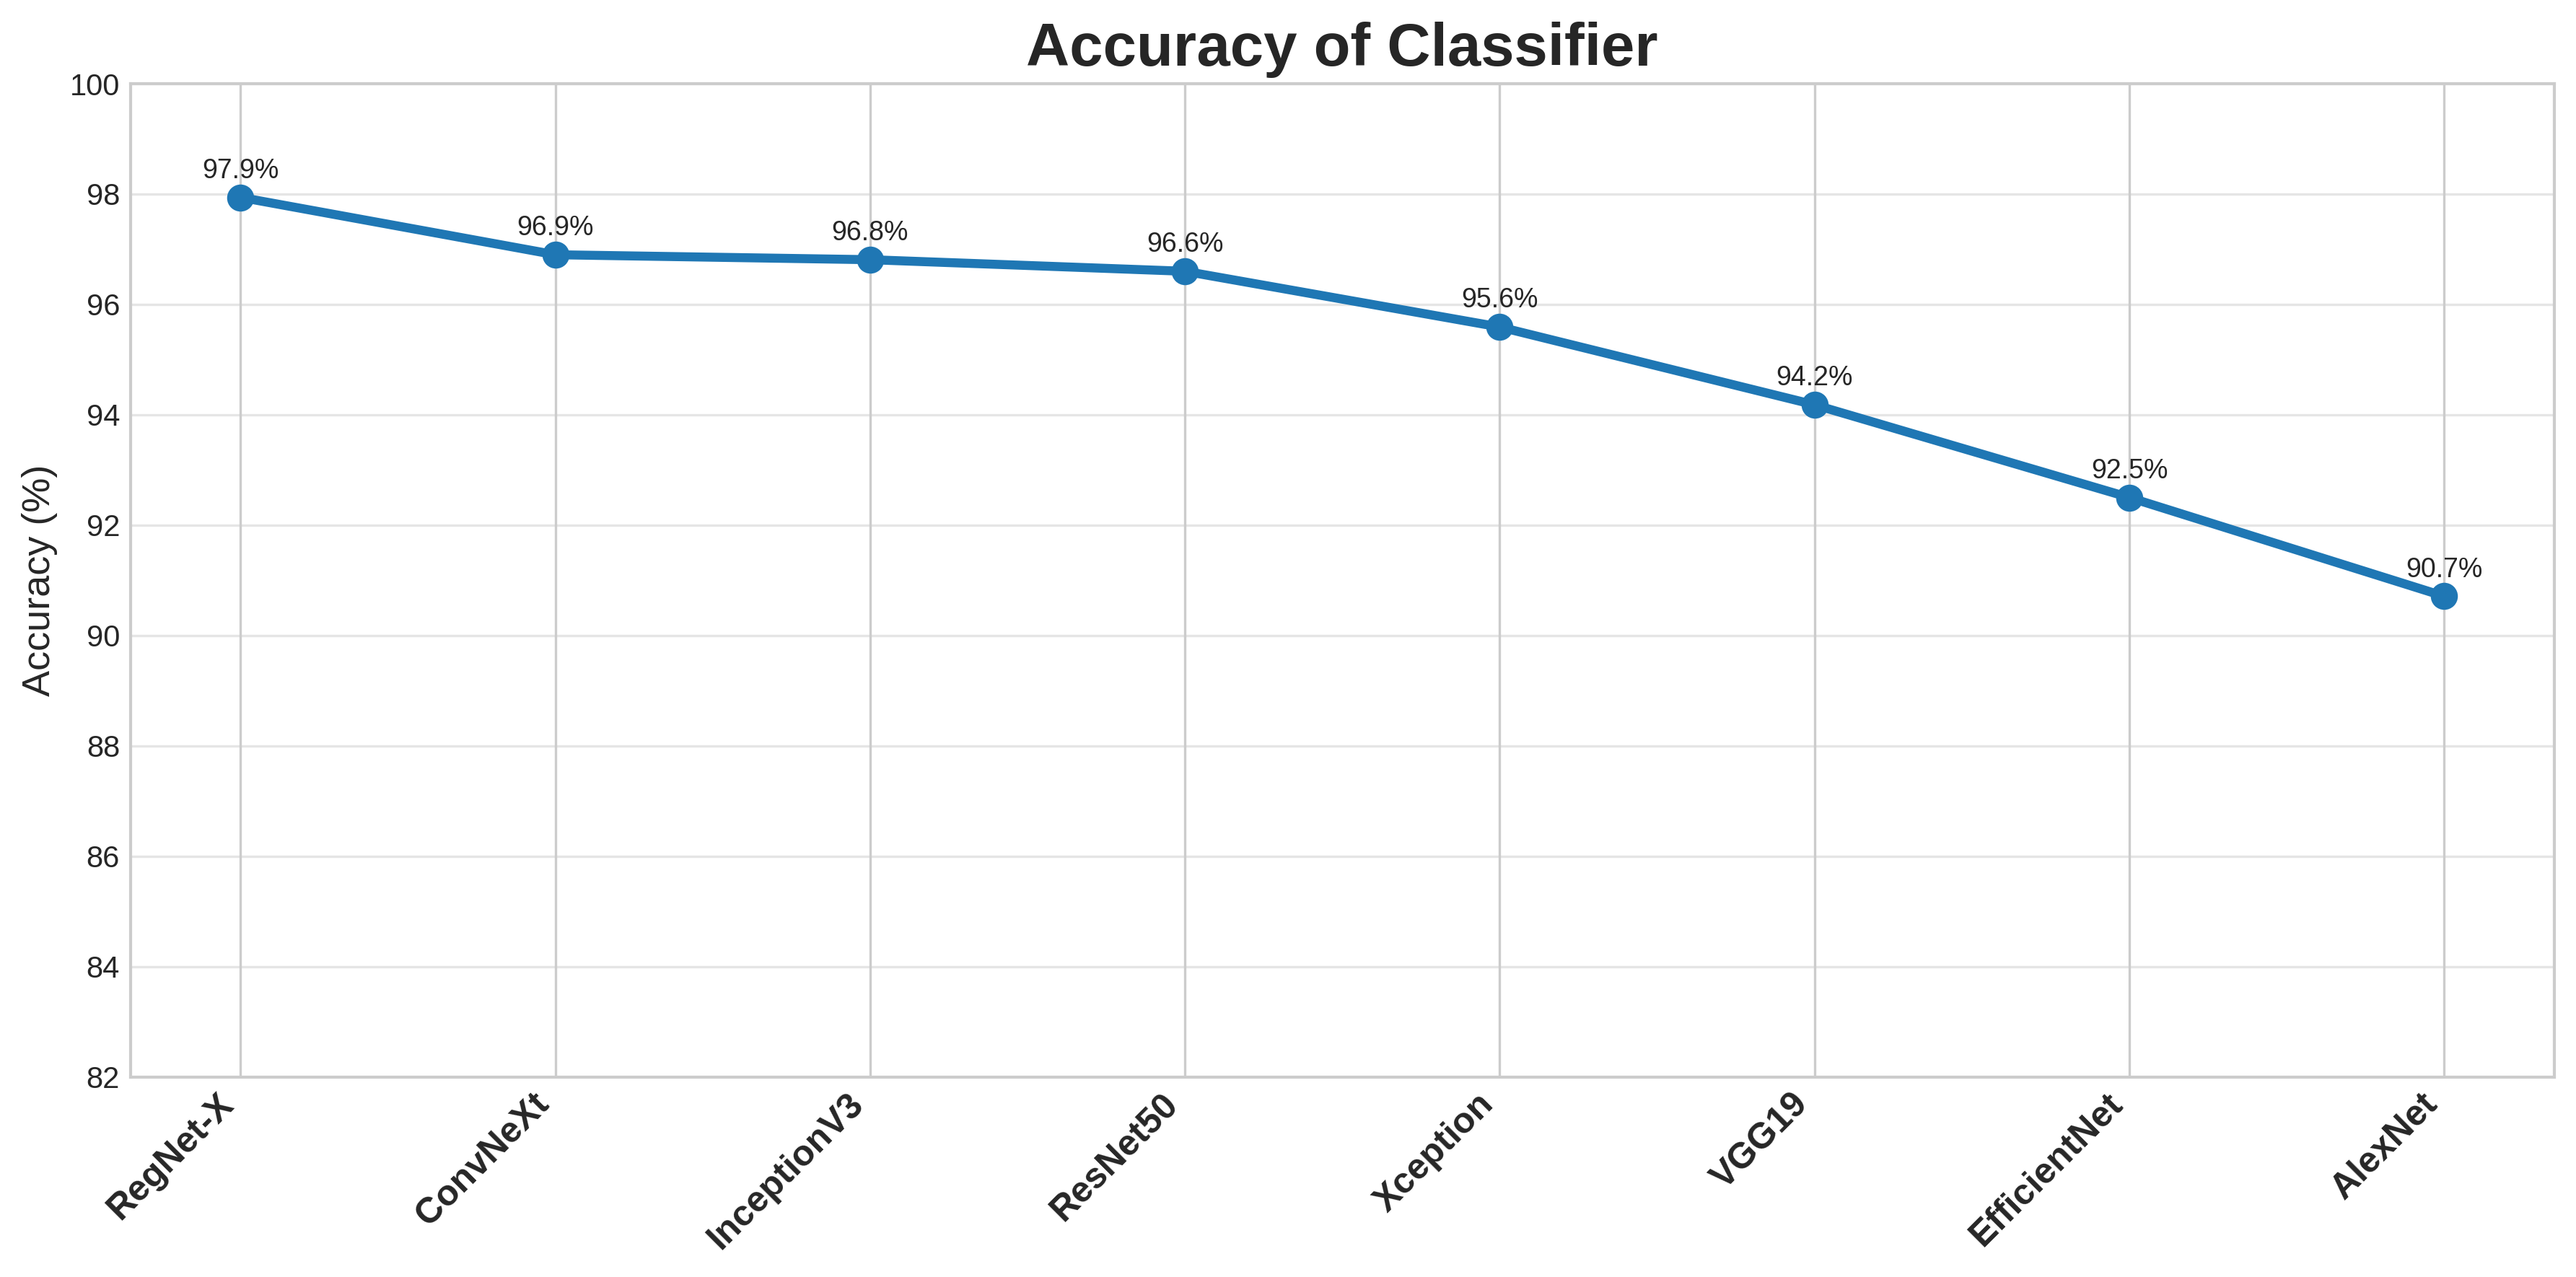

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["RegNet-X", "ConvNeXt", "InceptionV3", "ResNet50",
          "Xception", "VGG19", "EfficientNet", "AlexNet"]

accuracy = [97.94, 96.90, 96.81, 96.60, 95.59, 94.18, 92.50, 90.71]

plt.figure(figsize=(12, 6), dpi=300)

plt.plot(
    models,
    accuracy,
    marker="o",
    linewidth=3,
    markersize=8
)

plt.title("Accuracy of Classifier", fontsize=20, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=13)

plt.ylim(82, 100)
plt.yticks(np.arange(82, 101, 2))

plt.xticks(rotation=45, ha="right", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle="-", alpha=0.5)

for i, acc in enumerate(accuracy):
    plt.text(i, acc + 0.35, f"{acc:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("accuracy_of_classifier.png", dpi=300, bbox_inches="tight")
plt.show()

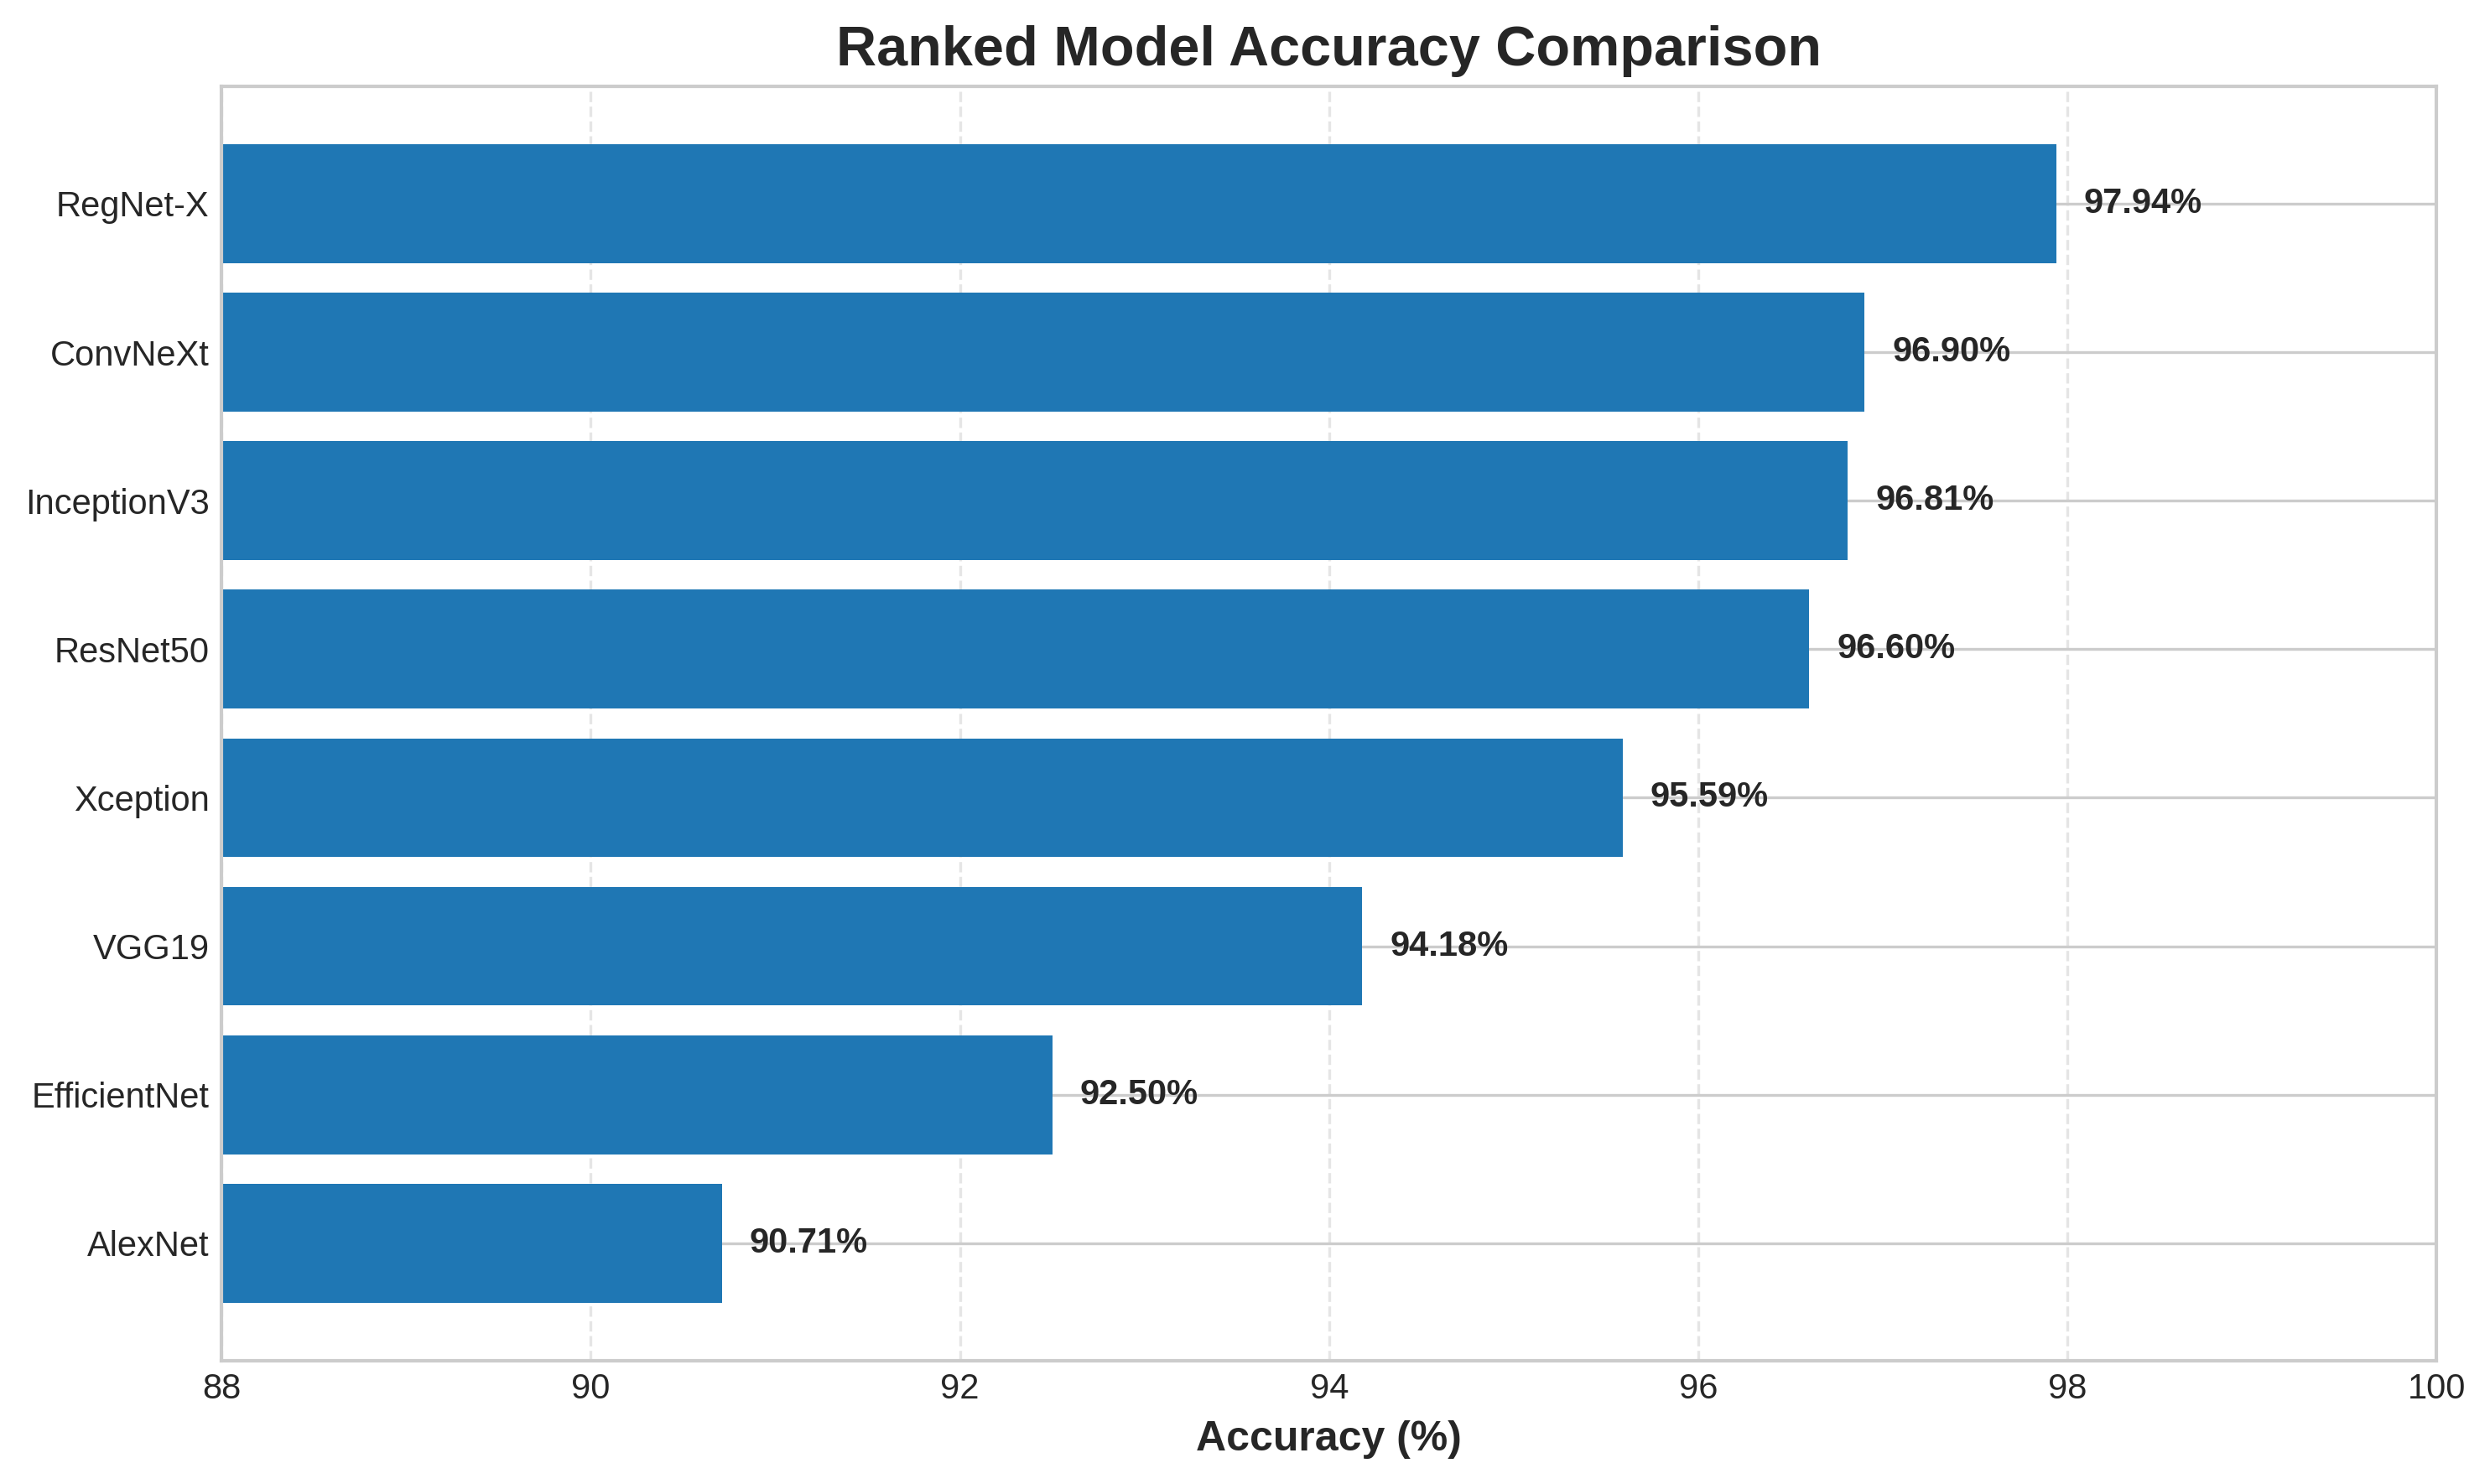

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["RegNet-X", "ConvNeXt", "InceptionV3", "ResNet50",
          "Xception", "VGG19", "EfficientNet", "AlexNet"]

accuracy = [97.94, 96.90, 96.81, 96.60, 95.59, 94.18, 92.50, 90.71]

# Sort from lowest to highest so best appears at top after barh
sorted_data = sorted(zip(models, accuracy), key=lambda x: x[1])
models_sorted = [m[0] for m in sorted_data]
accuracy_sorted = [m[1] for m in sorted_data]

plt.figure(figsize=(10, 6), dpi=300)

bars = plt.barh(models_sorted, accuracy_sorted)

plt.xlabel("Accuracy (%)", fontsize=12, fontweight="bold")
plt.title("Ranked Model Accuracy Comparison", fontsize=16, fontweight="bold")

plt.xlim(88, 100)
plt.xticks(np.arange(88, 101, 2))

plt.grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.15,
             bar.get_y() + bar.get_height()/2,
             f"{width:.2f}%",
             va="center",
             fontsize=10,
             fontweight="bold")

plt.tight_layout()
plt.savefig("ranked_model_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

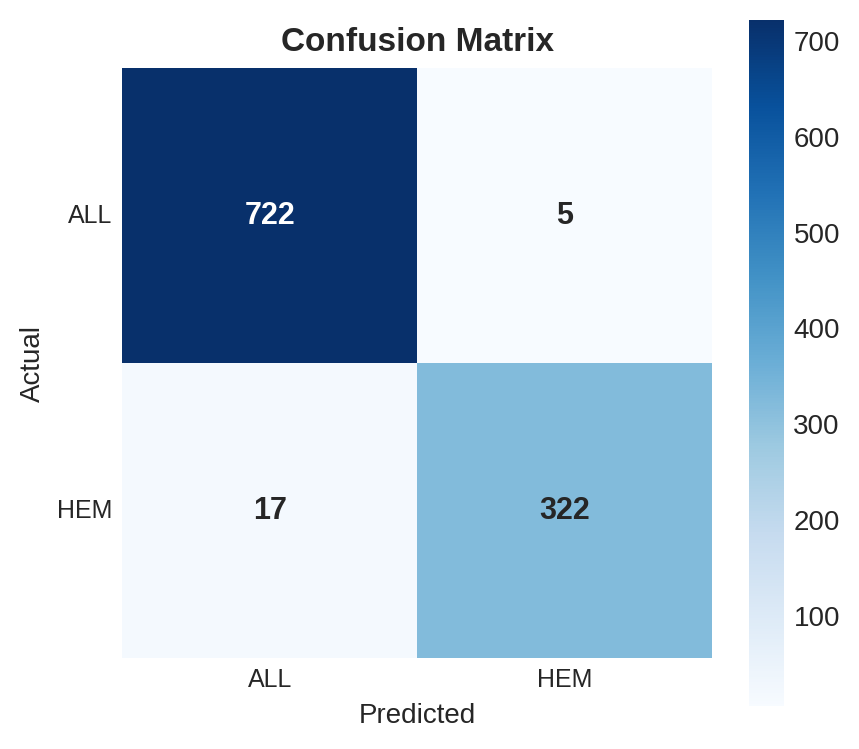

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your confusion matrix (replace if needed)
cm = np.array([
    [722, 5],
    [17, 322]
])

labels = ["ALL", "HEM"]

plt.figure(figsize=(4.5, 4), dpi=200)  # 🔥 smaller + sharp

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
    square=True,              # 🔥 makes it neat
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title("Confusion Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Predicted", fontsize=10)
plt.ylabel("Actual", fontsize=10)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix_clean.png", dpi=300, bbox_inches="tight")
plt.show()

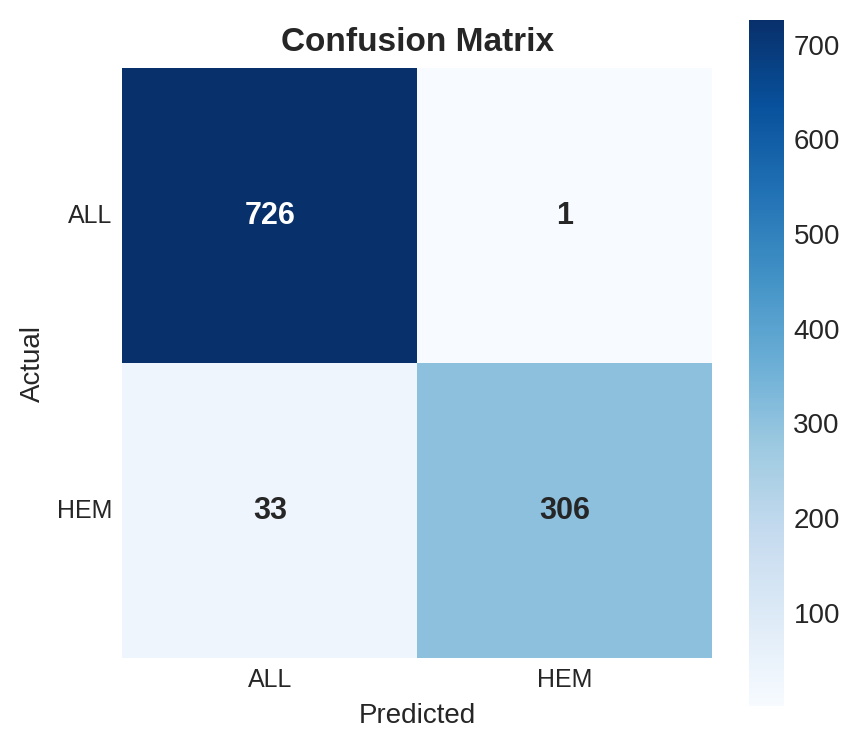

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load best ConvNeXt model
convnext_model.load_state_dict(torch.load("/content/best_convnext_final.pth"))
convnext_model = convnext_model.to(device)
convnext_model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)

        outputs = convnext_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

# Convert to numpy
all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)

# Plot
plt.figure(figsize=(4.5, 4), dpi=200)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ALL", "HEM"],
    yticklabels=["ALL", "HEM"],
    square=True,
    cbar=True,
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title("Confusion Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Predicted", fontsize=10)
plt.ylabel("Actual", fontsize=10)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig("convnext_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()